# CLARITY / QEvasion Paper-Ready Results Analysis

This notebook analyzes saved experiment outputs for SemEval-2026 Task 6 CLARITY: *Unmasking Political Question Evasions*.

It does not train models. It discovers available data, predictions, metrics, configs, and logs; computes paper-ready tables and figures; and writes all generated artifacts under `paper_assets/`.

The notebook is intentionally conservative: if an experiment or column is missing, the corresponding analysis is skipped with a warning rather than invented.

## 1. Imports and Configuration

Set the repository root, likely input directories, max sequence length used for length/truncation analysis, and random seed for reproducible example sampling.

In [28]:
from __future__ import annotations

import json
import math
import re
import textwrap
import warnings
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

MAX_SEQUENCE_LENGTH = 512
DATA_DIR_CANDIDATES = [
    ROOT / "data",
    ROOT / "outputs",
    ROOT / "outputs" / "runs",
    ROOT / "notebooks",
]
RESULT_DIR_CANDIDATES = [
    ROOT / "outputs",
    ROOT / "outputs" / "runs",
    ROOT / "outputs" / "ensembles",
    ROOT / "outputs" / "hierarchical",
]

ASSET_DIR = ROOT / "paper_assets"
TABLE_DIR = ASSET_DIR / "tables"
FIGURE_DIR = ASSET_DIR / "figures"
EXAMPLE_DIR = ASSET_DIR / "examples"
DRAFT_DIR = ASSET_DIR / "drafts"
for directory in [ASSET_DIR, TABLE_DIR, FIGURE_DIR, EXAMPLE_DIR, DRAFT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 160)
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
})

print(f"Repository root: {ROOT}")
print(f"Paper assets: {ASSET_DIR}")

Repository root: /lustre/mlnvme/data/s18qzhao_hpc-project/playground/Project-MMD2-git
Paper assets: /lustre/mlnvme/data/s18qzhao_hpc-project/playground/Project-MMD2-git/paper_assets


## 2. File Discovery

This section inventories likely data, prediction, score, config, and log files. The inventory is used to avoid unsupported claims in the paper.

In [29]:
SUPPORTED_EXTENSIONS = {".csv", ".tsv", ".json", ".jsonl", ".parquet", ".txt", ".log", ".yaml", ".yml", ".npy"}
EXCLUDED_PARTS = {".git", ".venv", "__pycache__", ".ipynb_checkpoints", "paper_assets"}


def warn(message: str) -> None:
    print(f"WARNING: {message}")


def safe_rel(path: Path) -> str:
    try:
        return str(path.relative_to(ROOT))
    except ValueError:
        return str(path)


def guess_role(path: Path) -> str:
    text = safe_rel(path).lower()
    name = path.name.lower()
    if "prediction" in name or "predictions" in name or "probabilities" in name or "logits" in name:
        return "prediction"
    if "metrics" in name or "results_summary" in name or "classification_report" in name or "confusion_matrix" in name:
        return "score"
    if "submission" in name:
        return "submission"
    if path.suffix.lower() in {".log", ".out", ".err", ".txt"} or "slurm_logs" in text:
        return "log"
    if path.suffix.lower() in {".yaml", ".yml"} and "config" in text:
        return "config"
    if any(token in text for token in ["train", "dev", "validation", "test", "dataset", "split"]):
        return "data"
    return "unknown"



def guess_task(path: Path) -> str:
    text = safe_rel(path).lower()
    parts = [part.lower() for part in path.parts]

    # Most reliable signal for this repository:
    # outputs/runs/multitask/<run>/artifacts/task1/test_predictions.csv
    # outputs/runs/multitask/<run>/artifacts/task2/test_predictions.csv
    if "artifacts" in parts:
        idx = len(parts) - 1 - parts[::-1].index("artifacts")
        if idx + 1 < len(parts) and parts[idx + 1] in {"task1", "task2"}:
            return parts[idx + 1]

    # Exact path components are more reliable than substrings in long run names.
    has_task1_part = "task1" in parts
    has_task2_part = "task2" in parts
    if has_task1_part and not has_task2_part:
        return "task1"
    if has_task2_part and not has_task1_part:
        return "task2"

    has_task1 = "task1" in text or "clarity" in text
    has_task2 = "task2" in text or "evasion" in text
    if has_task1 and not has_task2:
        return "task1"
    if has_task2 and not has_task1:
        return "task2"
    if "multitask" in text or (has_task1 and has_task2):
        return "both"
    return "unknown"


def discover_files(root: Path) -> pd.DataFrame:
    rows = []
    for path in root.rglob("*"):
        if not path.is_file():
            continue
        if any(part in EXCLUDED_PARTS for part in path.parts):
            continue
        if path.suffix.lower() not in SUPPORTED_EXTENSIONS:
            continue
        stat = path.stat()
        rows.append({
            "path": safe_rel(path),
            "name": path.name,
            "extension": path.suffix.lower(),
            "size_bytes": stat.st_size,
            "modified_time": pd.to_datetime(stat.st_mtime, unit="s"),
            "role": guess_role(path),
            "task": guess_task(path),
        })
    return pd.DataFrame(rows).sort_values(["role", "task", "path"]).reset_index(drop=True)


file_inventory = discover_files(ROOT)
file_inventory.to_csv(TABLE_DIR / "discovered_files.csv", index=False)
display(file_inventory.head(50))
print(f"Discovered {len(file_inventory)} candidate files.")

,path,name,extension,size_bytes,modified_time,role,task
0,configs/deberta_v3_base_multitask.yaml,deberta_v3_base_multitask.yaml,.yaml,535,2026-06-17 12:58:57,config,both
1,outputs/runs/multitask/deberta_v3_base_multitask_microsoft_deberta_v3_base_multitask_seed42_20260617_005757/config.yaml,config.yaml,.yaml,1217,2026-06-17 12:58:58,config,both
2,configs/bert_base_task1.yaml,bert_base_task1.yaml,.yaml,422,2026-06-17 12:58:57,config,task1
3,configs/deberta_v3_base_task1.yaml,deberta_v3_base_task1.yaml,.yaml,463,2026-06-17 12:58:57,config,task1
4,configs/deberta_v3_base_task1_politician_answer.yaml,deberta_v3_base_task1_politician_answer.yaml,.yaml,491,2026-06-17 12:58:57,config,task1
5,configs/deberta_v3_base_task1_weighted.yaml,deberta_v3_base_task1_weighted.yaml,.yaml,480,2026-06-17 12:58:57,config,task1
6,configs/deberta_v3_large_task1.yaml,deberta_v3_large_task1.yaml,.yaml,517,2026-06-17 12:58:57,config,task1
7,configs/deberta_xlarge_task1.yaml,deberta_xlarge_task1.yaml,.yaml,529,2026-06-17 12:58:57,config,task1
8,configs/roberta_large_task1.yaml,roberta_large_task1.yaml,.yaml,472,2026-06-17 12:58:57,config,task1
9,outputs/runs/task1/bert_base_task1_bert_base_uncased_task1_seed42_20260617_004218/config.yaml,config.yaml,.yaml,1190,2026-06-17 12:59:00,config,task1


Discovered 599 candidate files.


## 3. Robust Loading and Column Detection

The helpers below load common file types, normalize label variants, detect useful columns, and standardize prediction files.

In [30]:
TASK1_CANONICAL = {
    "clear reply": "Clear Reply",
    "clear_reply": "Clear Reply",
    "ambiguous": "Ambivalent",
    "ambivalent": "Ambivalent",
    "ambivalent reply": "Ambivalent",
    "clear non reply": "Clear Non-Reply",
    "clear non-reply": "Clear Non-Reply",
    "clear_non_reply": "Clear Non-Reply",
}

TASK2_CANONICAL = {
    "explicit": "Explicit",
    "implicit": "Implicit",
    "dodging": "Dodging",
    "general": "General",
    "deflection": "Deflection",
    "partial/half-answer": "Partial/half-answer",
    "partial half answer": "Partial/half-answer",
    "declining to answer": "Declining to answer",
    "claims ignorance": "Claims ignorance",
    "clarification": "Clarification",
}

ID_CANDIDATES = ["example_id", "id", "index", "row_idx", "qid"]
QUESTION_CANDIDATES = ["question", "interview_question", "query"]
ANSWER_CANDIDATES = ["answer", "interview_answer", "response", "reply"]
GOLD_CANDIDATES = ["gold_label", "label", "clarity_label", "evasion_label", "majority_label", "unanimous_label"]
TASK1_GOLD_CANDIDATES = ["gold_label", "clarity_label", "label"]
TASK2_GOLD_CANDIDATES = ["majority_label", "gold_label", "evasion_label", "unanimous_label", "label"]
PRED_CANDIDATES = ["predicted_label", "prediction", "pred", "ensemble_predicted_label", "hierarchical_task2_prediction"]
ANNOTATOR_CANDIDATES = ["annotator1", "annotator2", "annotator3", "label_1", "label_2", "label_3"]
TASK1_LABELS = ["Clear Reply", "Ambivalent", "Clear Non-Reply"]
TASK2_LABELS = [
    "Explicit",
    "Implicit",
    "Dodging",
    "General",
    "Deflection",
    "Partial/half-answer",
    "Declining to answer",
    "Claims ignorance",
    "Clarification",
]
TASK1_LABEL_SET = set(TASK1_LABELS)
TASK2_LABEL_SET = set(TASK2_LABELS)


def load_table(path: Path):
    suffix = path.suffix.lower()
    try:
        if suffix == ".csv":
            return pd.read_csv(path)
        if suffix == ".tsv":
            return pd.read_csv(path, sep="\t")
        if suffix == ".jsonl":
            return pd.read_json(path, lines=True)
        if suffix == ".json":
            with path.open("r", encoding="utf-8") as f:
                obj = json.load(f)
            if isinstance(obj, list):
                return pd.DataFrame(obj)
            if isinstance(obj, dict):
                return obj
        if suffix == ".parquet":
            return pd.read_parquet(path)
    except Exception as exc:
        warn(f"Could not load {safe_rel(path)}: {exc}")
    return None


def first_existing(columns, candidates):
    lowered = {str(column).lower(): column for column in columns}
    for candidate in candidates:
        if candidate.lower() in lowered:
            return lowered[candidate.lower()]
    return None


def find_columns(columns, patterns):
    found = []
    for column in columns:
        lower = str(column).lower()
        if any(re.search(pattern, lower) for pattern in patterns):
            found.append(column)
    return found


def normalize_label(value, task=None):
    if pd.isna(value):
        return np.nan
    text = str(value).strip()
    if not text:
        return np.nan
    key = re.sub(r"\s+", " ", text.replace("_", " ")).strip().lower()
    if task == "task1":
        return TASK1_CANONICAL.get(key, text)
    if task == "task2":
        return TASK2_CANONICAL.get(key, text)
    return TASK1_CANONICAL.get(key, TASK2_CANONICAL.get(key, text))


def infer_split_from_path(path: Path) -> str:
    text = safe_rel(path).lower()
    name = path.name.lower()
    if "dev_" in name or "_dev" in name or "validation" in text or "eval" in text:
        return "dev"
    if "test_" in name or "_test" in name or "/test" in text:
        return "test"
    if "train" in text:
        return "train"
    return "unknown"


def infer_experiment_from_path(path: Path) -> str:
    parts = path.parts
    if "runs" in parts:
        idx = parts.index("runs")
        if len(parts) > idx + 2:
            return parts[idx + 2]
    return path.parent.name



def infer_task_from_df_path(df: pd.DataFrame, path: Path) -> str:
    task = guess_task(path)
    if task in {"task1", "task2"}:
        return task

    # If the path is ambiguous, use label/probability columns before annotator
    # columns. Task 1 test files also contain annotator columns from the raw
    # dataset, so annotators alone must not force Task 2.
    columns = set(df.columns)
    prob_cols = [str(c).lower() for c in columns if str(c).lower().startswith("prob_")]
    if any(c in prob_cols for c in ["prob_clear_reply", "prob_ambivalent", "prob_clear_non_reply"]):
        return "task1"
    if any(c in prob_cols for c in ["prob_explicit", "prob_dodging", "prob_general", "prob_deflection"]):
        return "task2"
    if column_has_task_labels(df, "gold_label", "task1") or column_has_task_labels(df, "clarity_label", "task1"):
        return "task1"
    if (
        column_has_task_labels(df, "majority_label", "task2")
        or column_has_task_labels(df, "evasion_label", "task2")
        or column_has_task_labels(df, "gold_label", "task2")
    ):
        return "task2"
    if {"annotator1", "annotator2", "annotator3"}.issubset(columns):
        return "task2"
    return "unknown"


def probability_columns(df: pd.DataFrame):
    return [c for c in df.columns if str(c).lower().startswith("prob_")]


def confidence_from_row(row, prob_cols):
    if not prob_cols:
        return np.nan
    values = pd.to_numeric(row[prob_cols], errors="coerce").dropna()
    if values.empty:
        return np.nan
    return float(values.max())


def majority_label_from_values(values, task="task2"):
    clean = [normalize_label(v, task) for v in values if pd.notna(v) and str(v).strip()]
    counts = Counter(clean)
    for label, count in counts.most_common():
        if count >= 2:
            return label
    return np.nan


def unanimous_label_from_values(values, task="task2"):
    clean = [normalize_label(v, task) for v in values if pd.notna(v) and str(v).strip()]
    return clean[0] if len(clean) == 3 and len(set(clean)) == 1 else np.nan


def column_has_task_labels(df: pd.DataFrame, column: str, task: str) -> bool:
    if column not in df.columns:
        return False
    labels = df[column].dropna().map(lambda x: normalize_label(x, task))
    labels = set(labels.dropna().astype(str))
    if task == "task1":
        return bool(labels & TASK1_LABEL_SET)
    if task == "task2":
        return bool(labels & TASK2_LABEL_SET)
    return bool(labels)


def select_gold_column(df: pd.DataFrame, task: str):
    if task == "task2":
        for column in TASK2_GOLD_CANDIDATES:
            if column_has_task_labels(df, column, "task2"):
                return column
        return None
    if task == "task1":
        for column in TASK1_GOLD_CANDIDATES:
            if column_has_task_labels(df, column, "task1"):
                return column
        return None
    return first_existing(df.columns, GOLD_CANDIDATES)


def standardize_prediction_frame(path: Path, df: pd.DataFrame):
    if df is None or not isinstance(df, pd.DataFrame) or df.empty:
        return None
    task = infer_task_from_df_path(df, path)
    split = infer_split_from_path(path)
    df = df.copy()
    annotator_cols_here = [col for col in ANNOTATOR_CANDIDATES if col in df.columns]
    if task == "task2" and len(annotator_cols_here) >= 2:
        if "majority_label" not in df.columns or not column_has_task_labels(df, "majority_label", "task2"):
            df["majority_label"] = df[annotator_cols_here].apply(
                lambda row: majority_label_from_values(row, "task2"),
                axis=1,
            )
        if "unanimous_label" not in df.columns or not column_has_task_labels(df, "unanimous_label", "task2"):
            df["unanimous_label"] = df[annotator_cols_here].apply(
                lambda row: unanimous_label_from_values(row, "task2"),
                axis=1,
            )

    pred_col = first_existing(df.columns, PRED_CANDIDATES)
    gold_col = select_gold_column(df, task)
    if pred_col is None:
        warn(f"Prediction file skipped, no prediction column detected: {safe_rel(path)}")
        return None
    if gold_col is None:
        warn(f"Prediction file has no usable {task} gold/majority label column; metrics skipped for {safe_rel(path)}")
    out = df.copy()
    out["source_file"] = safe_rel(path)
    out["experiment"] = infer_experiment_from_path(path)
    out["task"] = task
    out["split"] = split
    out["prediction"] = out[pred_col].map(lambda x: normalize_label(x, task))
    out["gold"] = out[gold_col].map(lambda x: normalize_label(x, task)) if gold_col else np.nan
    id_col = first_existing(out.columns, ID_CANDIDATES)
    q_col = first_existing(out.columns, QUESTION_CANDIDATES)
    a_col = first_existing(out.columns, ANSWER_CANDIDATES)
    out["example_id_std"] = out[id_col] if id_col else np.arange(len(out))
    out["question_std"] = out[q_col] if q_col else ""
    out["answer_std"] = out[a_col] if a_col else ""
    prob_cols = probability_columns(out)
    out["confidence"] = out.apply(lambda row: confidence_from_row(row, prob_cols), axis=1) if prob_cols else np.nan
    out["correct"] = np.where(out["gold"].notna(), out["gold"] == out["prediction"], np.nan)
    return out

## 4. Load Predictions, Metrics, and Run Summaries

This section loads the files actually present in the repository. It supports the output format from this project (`outputs/runs/.../artifacts/*_predictions.csv`) and keeps unknown files out of metric tables.

In [31]:
prediction_paths = [
    ROOT / row.path
    for row in file_inventory.itertuples(index=False)
    if row.role == "prediction" and row.extension in {".csv", ".tsv", ".json", ".jsonl", ".parquet"}
]

prediction_frames = []
for path in prediction_paths:
    loaded = load_table(path)
    if isinstance(loaded, pd.DataFrame):
        standardized = standardize_prediction_frame(path, loaded)
        if standardized is not None:
            prediction_frames.append(standardized)

predictions = pd.concat(prediction_frames, ignore_index=True) if prediction_frames else pd.DataFrame()
print(f"Loaded {len(prediction_frames)} prediction files with {len(predictions)} rows.")
if not predictions.empty:
    display(predictions[["source_file", "experiment", "task", "split", "gold", "prediction", "correct", "confidence"]].head())
else:
    warn("No usable prediction files were found. Metric sections will be skipped until outputs are available.")


def flatten_metrics(prefix, metrics):
    rows = []
    if isinstance(metrics, dict):
        row = {}
        for key, value in metrics.items():
            if isinstance(value, (int, float, str)) or value is None:
                row[f"{prefix}{key}"] = value
        rows.append(row)
    return rows


summary_rows = []
for path in sorted((ROOT / "outputs" / "runs").glob("*/*/results_summary.json")):
    try:
        summary = load_table(path)
    except Exception:
        summary = None
    if not isinstance(summary, dict):
        continue
    base = {
        "run_dir": safe_rel(path.parent),
        "run_name": path.parent.name,
        "task_type": summary.get("task"),
        "model_name": summary.get("model_name"),
        "seed": summary.get("seed"),
        "experiment_name": summary.get("experiment_name"),
    }
    if summary.get("task") == "multitask":
        for task in ["task1", "task2"]:
            dev = summary.get("dev_metrics", {}).get(task, {})
            test = summary.get("test_metrics", {}).get(task, {})
            summary_rows.append({
                **base,
                "task": task,
                "dev_macro_f1": dev.get("macro_f1"),
                "test_macro_f1": test.get("macro_f1", test.get("majority_macro_f1")),
                "test_unanimous_macro_f1": test.get("unanimous_macro_f1"),
                "any_annotator_match_rate": test.get("any_annotator_match_rate"),
                "unresolved_disagreement_count": test.get("unresolved_disagreement_count"),
            })
    else:
        dev = summary.get("dev_metrics", {})
        test = summary.get("test_metrics", {})
        summary_rows.append({
            **base,
            "task": summary.get("task"),
            "dev_macro_f1": dev.get("macro_f1"),
            "test_macro_f1": test.get("macro_f1", test.get("majority_macro_f1")),
            "test_unanimous_macro_f1": test.get("unanimous_macro_f1"),
            "any_annotator_match_rate": test.get("any_annotator_match_rate"),
            "unresolved_disagreement_count": test.get("unresolved_disagreement_count"),
        })

run_summaries = pd.DataFrame(summary_rows)
if not run_summaries.empty:
    run_summaries.to_csv(TABLE_DIR / "run_summary_metrics.csv", index=False)
    display(run_summaries.sort_values(["task", "test_macro_f1"], ascending=[True, False]).head(30))
else:
    warn("No results_summary.json files found.")

Loaded 32 prediction files with 15968 rows.


,source_file,experiment,task,split,gold,prediction,correct,confidence
0,outputs/runs/multitask/deberta_v3_base_multitask_microsoft_deberta_v3_base_multitask_seed42_20260617_005757/artifacts/task1/dev_predictions.csv,deberta_v3_base_multitask_microsoft_deberta_v3_base_multitask_seed42_20260617_005757,task1,dev,Ambivalent,Ambivalent,1.0,0.891034
1,outputs/runs/multitask/deberta_v3_base_multitask_microsoft_deberta_v3_base_multitask_seed42_20260617_005757/artifacts/task1/dev_predictions.csv,deberta_v3_base_multitask_microsoft_deberta_v3_base_multitask_seed42_20260617_005757,task1,dev,Clear Non-Reply,Clear Reply,0.0,0.854412
2,outputs/runs/multitask/deberta_v3_base_multitask_microsoft_deberta_v3_base_multitask_seed42_20260617_005757/artifacts/task1/dev_predictions.csv,deberta_v3_base_multitask_microsoft_deberta_v3_base_multitask_seed42_20260617_005757,task1,dev,Ambivalent,Ambivalent,1.0,0.873627
3,outputs/runs/multitask/deberta_v3_base_multitask_microsoft_deberta_v3_base_multitask_seed42_20260617_005757/artifacts/task1/dev_predictions.csv,deberta_v3_base_multitask_microsoft_deberta_v3_base_multitask_seed42_20260617_005757,task1,dev,Clear Reply,Ambivalent,0.0,0.916612
4,outputs/runs/multitask/deberta_v3_base_multitask_microsoft_deberta_v3_base_multitask_seed42_20260617_005757/artifacts/task1/dev_predictions.csv,deberta_v3_base_multitask_microsoft_deberta_v3_base_multitask_seed42_20260617_005757,task1,dev,Ambivalent,Clear Non-Reply,0.0,0.492716


,run_dir,run_name,task_type,model_name,seed,experiment_name,task,dev_macro_f1,test_macro_f1,test_unanimous_macro_f1,any_annotator_match_rate,unresolved_disagreement_count
7,outputs/runs/task1/deberta_xlarge_task1_microsoft_deberta_xlarge_task1_seed42_20260617_005356,deberta_xlarge_task1_microsoft_deberta_xlarge_task1_seed42_20260617_005356,task1,microsoft/deberta-xlarge,42,deberta_xlarge_task1,task1,0.686600,0.631590,NaN,NaN,NaN
3,outputs/runs/task1/deberta_v3_base_task1_microsoft_deberta_v3_base_task1_seed42_20260617_004551,deberta_v3_base_task1_microsoft_deberta_v3_base_task1_seed42_20260617_004551,task1,microsoft/deberta-v3-base,42,deberta_v3_base_task1,task1,0.663508,0.604594,NaN,NaN,NaN
8,outputs/runs/task1/roberta_large_task1_roberta_large_task1_seed42_20260617_004215,roberta_large_task1_roberta_large_task1_seed42_20260617_004215,task1,roberta-large,42,roberta_large_task1,task1,0.676774,0.596396,NaN,NaN,NaN
6,outputs/runs/task1/deberta_v3_large_task1_microsoft_deberta_v3_large_task1_seed42_20260617_004218,deberta_v3_large_task1_microsoft_deberta_v3_large_task1_seed42_20260617_004218,task1,microsoft/deberta-v3-large,42,deberta_v3_large_task1,task1,0.690275,0.594646,NaN,NaN,NaN
4,outputs/runs/task1/deberta_v3_base_task1_politician_answer_microsoft_deberta_v3_base_task1_seed42_20260617_005355,deberta_v3_base_task1_politician_answer_microsoft_deberta_v3_base_task1_seed42_20260617_005355,task1,microsoft/deberta-v3-base,42,deberta_v3_base_task1_politician_answer,task1,0.671444,0.587542,NaN,NaN,NaN
0,outputs/runs/multitask/deberta_v3_base_multitask_microsoft_deberta_v3_base_multitask_seed42_20260617_005757,deberta_v3_base_multitask_microsoft_deberta_v3_base_multitask_seed42_20260617_005757,multitask,microsoft/deberta-v3-base,42,deberta_v3_base_multitask,task1,0.676042,0.586181,NaN,NaN,NaN
2,outputs/runs/task1/bert_base_task1_bert_base_uncased_task1_seed42_20260617_004218,bert_base_task1_bert_base_uncased_task1_seed42_20260617_004218,task1,bert-base-uncased,42,bert_base_task1,task1,0.575503,0.569630,NaN,NaN,NaN
5,outputs/runs/task1/deberta_v3_base_task1_weighted_microsoft_deberta_v3_base_task1_seed42_20260617_004953,deberta_v3_base_task1_weighted_microsoft_deberta_v3_base_task1_seed42_20260617_004953,task1,microsoft/deberta-v3-base,42,deberta_v3_base_task1_weighted,task1,0.630792,0.546232,NaN,NaN,NaN
15,outputs/runs/task2/roberta_large_task2_roberta_large_task2_seed42_20260617_004218,roberta_large_task2_roberta_large_task2_seed42_20260617_004218,task2,roberta-large,42,roberta_large_task2,task2,0.374746,0.342051,0.401895,0.525974,33.0
13,outputs/runs/task2/deberta_v3_large_task2_microsoft_deberta_v3_large_task2_seed42_20260617_005310,deberta_v3_large_task2_microsoft_deberta_v3_large_task2_seed42_20260617_005310,task2,microsoft/deberta-v3-large,42,deberta_v3_large_task2,task2,0.368063,0.325411,0.386694,0.542208,33.0


## 5. Dataset Analysis

The notebook uses available train/dev/test data files when present. If raw data files are absent, it uses prediction files as an analysis proxy for examples, labels, metadata, and lengths.

In [32]:
def add_text_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    question = out.get("question_std", pd.Series([""] * len(out))).fillna("").astype(str)
    answer = out.get("answer_std", pd.Series([""] * len(out))).fillna("").astype(str)
    out["question_words"] = question.str.split().map(len)
    out["answer_words"] = answer.str.split().map(len)
    out["total_words"] = out["question_words"] + out["answer_words"] + 2
    out["question_marks"] = question.str.count(r"\?")
    out["likely_multipart_question"] = (
        (out["question_marks"] >= 2)
        | question.str.contains(r"\band\b|also|separately|second|follow[- ]?up", case=False, regex=True, na=False)
    )
    out["approx_tokens"] = out["total_words"]
    out["likely_truncated"] = out["approx_tokens"] > MAX_SEQUENCE_LENGTH
    return out


analysis_examples = add_text_features(predictions) if not predictions.empty else pd.DataFrame()

dataset_stats_rows = []
if not analysis_examples.empty:
    for (task, split), group in analysis_examples.groupby(["task", "split"], dropna=False):
        id_dupes = int(group["example_id_std"].duplicated().sum()) if "example_id_std" in group else 0
        qa_dupes = int(group[["question_std", "answer_std"]].duplicated().sum()) if {"question_std", "answer_std"}.issubset(group.columns) else 0
        dataset_stats_rows.append({
            "task": task,
            "split": split,
            "num_examples": len(group),
            "num_columns": group.shape[1],
            "missing_question": int(group["question_std"].isna().sum()) if "question_std" in group else np.nan,
            "missing_answer": int(group["answer_std"].isna().sum()) if "answer_std" in group else np.nan,
            "duplicate_ids": id_dupes,
            "duplicate_question_answer_pairs": qa_dupes,
            "mean_question_words": group["question_words"].mean(),
            "mean_answer_words": group["answer_words"].mean(),
            "mean_total_words": group["total_words"].mean(),
            "likely_truncated_rate": group["likely_truncated"].mean(),
        })
else:
    warn("Dataset analysis skipped because no examples were loaded.")

dataset_statistics = pd.DataFrame(dataset_stats_rows)
if not dataset_statistics.empty:
    dataset_statistics.to_csv(TABLE_DIR / "dataset_statistics.csv", index=False)
    display(dataset_statistics)


def label_distribution(df: pd.DataFrame, task: str) -> pd.DataFrame:
    if df.empty:
        return pd.DataFrame()
    subset = df[df["task"] == task].copy()
    if subset.empty or "gold" not in subset:
        return pd.DataFrame()
    rows = []
    for split, group in subset.groupby("split", dropna=False):
        counts = group["gold"].dropna().value_counts()
        total = counts.sum()
        for label, count in counts.items():
            rows.append({"task": task, "split": split, "label": label, "count": int(count), "percent": count / total if total else np.nan})
    return pd.DataFrame(rows)


label_dist_task1 = label_distribution(analysis_examples, "task1")
label_dist_task2 = label_distribution(analysis_examples, "task2")
if not label_dist_task1.empty:
    label_dist_task1.to_csv(TABLE_DIR / "label_distribution_task1.csv", index=False)
    display(label_dist_task1)
else:
    warn("Task 1 label distribution skipped.")
if not label_dist_task2.empty:
    label_dist_task2.to_csv(TABLE_DIR / "label_distribution_task2.csv", index=False)
    display(label_dist_task2)
else:
    warn("Task 2 label distribution skipped.")

,task,split,num_examples,num_columns,missing_question,missing_answer,duplicate_ids,duplicate_question_answer_pairs,mean_question_words,mean_answer_words,mean_total_words,likely_truncated_rate
0,task1,dev,5520,61,0,0,4830,4833,15.111594,316.514493,333.626087,0.230435
1,task1,test,2464,61,0,0,2156,2156,15.259740,326.308442,343.568182,0.233766
2,task2,dev,5520,61,0,0,4277,4286,13.969022,293.198913,309.167935,0.217754
3,task2,test,2464,61,0,0,2156,2156,15.259740,326.308442,343.568182,0.233766


,task,split,label,count,percent
0,task1,dev,Ambivalent,3264,0.591304
1,task1,dev,Clear Reply,1688,0.305797
2,task1,dev,Clear Non-Reply,568,0.102899
3,task1,test,Ambivalent,1648,0.668831
4,task1,test,Clear Reply,632,0.256494
5,task1,test,Clear Non-Reply,184,0.074675


,task,split,label,count,percent
0,task2,dev,Explicit,1688,0.305797
1,task2,dev,Dodging,1112,0.201449
2,task2,dev,Implicit,786,0.142391
3,task2,dev,Deflection,619,0.112138
4,task2,dev,General,616,0.111594
5,task2,dev,Declining to answer,230,0.041667
6,task2,dev,Claims ignorance,192,0.034783
7,task2,dev,Clarification,146,0.026449
8,task2,dev,Partial/half-answer,131,0.023732
9,task2,test,Explicit,616,0.280000


## 6. Dataset and Result Examples

This section writes copyable markdown files with representative dataset examples, long-answer examples, likely multi-part questions, correctly classified examples, and misclassified examples.

In [33]:
def short_text(value, width=900):
    text = "" if pd.isna(value) else str(value)
    return textwrap.shorten(" ".join(text.split()), width=width, placeholder=" ...")


def example_markdown(rows: pd.DataFrame, title: str, include_prediction: bool = False) -> str:
    lines = [f"# {title}", ""]
    if rows.empty:
        lines.append("_No examples available._")
        return "\n".join(lines)
    for idx, row in rows.reset_index(drop=True).iterrows():
        lines.append(f"## Example {idx + 1}")
        lines.append(f"- ID: `{row.get('example_id_std', '')}`")
        lines.append(f"- Task: `{row.get('task', '')}`")
        lines.append(f"- Split: `{row.get('split', '')}`")
        if "gold" in row and pd.notna(row.get("gold")):
            lines.append(f"- Gold: **{row.get('gold')}**")
        if include_prediction and "prediction" in row and pd.notna(row.get("prediction")):
            lines.append(f"- Prediction: **{row.get('prediction')}**")
        if include_prediction and "confidence" in row and pd.notna(row.get("confidence")):
            lines.append(f"- Confidence: `{row.get('confidence'):.3f}`")
        for meta in ["president", "speaker", "source", "date", "year", "url"]:
            if meta in row and pd.notna(row.get(meta)):
                lines.append(f"- {meta}: {row.get(meta)}")
        notes = []
        if row.get("likely_multipart_question", False):
            notes.append("likely multi-part question")
        if row.get("likely_truncated", False):
            notes.append("likely truncated")
        if pd.notna(row.get("confidence", np.nan)) and include_prediction:
            if row.get("correct") is False and row.get("confidence") >= 0.8:
                notes.append("high-confidence wrong prediction")
            if row.get("correct") is True and row.get("confidence") <= 0.5:
                notes.append("low-confidence correct prediction")
        if notes:
            lines.append(f"- Notes: {', '.join(notes)}")
        lines.append("")
        lines.append("**Question**")
        lines.append("")
        lines.append(short_text(row.get("question_std", "")))
        lines.append("")
        lines.append("**Answer**")
        lines.append("")
        lines.append(short_text(row.get("answer_std", "")))
        lines.append("")
    return "\n".join(lines)


def sample_by_label(df: pd.DataFrame, task: str, per_label: int) -> pd.DataFrame:
    subset = df[(df["task"] == task) & df["gold"].notna()].copy()
    if subset.empty:
        return pd.DataFrame()
    sampled = []
    for label, group in subset.groupby("gold"):
        sampled.append(group.sample(n=min(per_label, len(group)), random_state=RANDOM_SEED))
    return pd.concat(sampled).sort_values(["gold", "example_id_std"]) if sampled else pd.DataFrame()


if not analysis_examples.empty:
    task1_examples = sample_by_label(analysis_examples, "task1", 3)
    task2_examples = sample_by_label(analysis_examples, "task2", 2)
    long_answers = analysis_examples.sort_values("answer_words", ascending=False).head(12)
    multipart = analysis_examples[analysis_examples["likely_multipart_question"]].head(12)
    correct_examples = analysis_examples[analysis_examples["correct"] == True]
    wrong_examples = analysis_examples[analysis_examples["correct"] == False]

    (EXAMPLE_DIR / "dataset_examples_task1.md").write_text(example_markdown(task1_examples, "Task 1 Dataset Examples"), encoding="utf-8")
    (EXAMPLE_DIR / "dataset_examples_task2.md").write_text(example_markdown(task2_examples, "Task 2 Dataset Examples"), encoding="utf-8")
    (EXAMPLE_DIR / "long_answer_examples.md").write_text(example_markdown(long_answers, "Long Answer Examples"), encoding="utf-8")
    (EXAMPLE_DIR / "multipart_question_examples.md").write_text(example_markdown(multipart, "Likely Multi-Part Question Examples"), encoding="utf-8")
    (EXAMPLE_DIR / "correct_examples_task1.md").write_text(example_markdown(correct_examples[correct_examples["task"] == "task1"].head(18), "Correct Task 1 Examples", include_prediction=True), encoding="utf-8")
    (EXAMPLE_DIR / "correct_examples_task2.md").write_text(example_markdown(correct_examples[correct_examples["task"] == "task2"].head(18), "Correct Task 2 Examples", include_prediction=True), encoding="utf-8")
    (EXAMPLE_DIR / "error_examples_task1.md").write_text(example_markdown(wrong_examples[wrong_examples["task"] == "task1"].head(24), "Task 1 Error Examples", include_prediction=True), encoding="utf-8")
    (EXAMPLE_DIR / "error_examples_task2.md").write_text(example_markdown(wrong_examples[wrong_examples["task"] == "task2"].head(24), "Task 2 Error Examples", include_prediction=True), encoding="utf-8")
    print("Wrote example markdown files.")
else:
    warn("Example export skipped because no examples were loaded.")

Wrote example markdown files.


## 7. Length and Truncation Analysis

Approximate token length uses whitespace tokenization so the notebook does not require model tokenizers or internet access. If true tokenizer lengths are needed, they can be added later for the final selected model.

,task,split,examples,question_words_mean,question_words_median,answer_words_mean,answer_words_median,total_words_mean,total_words_p95,likely_truncated_rate,multipart_rate
0,task1,dev,5520,15.111594,13.0,316.514493,228.0,333.626087,987.0,0.230435,0.239130
1,task1,test,2464,15.259740,14.0,326.308442,291.5,343.568182,830.0,0.233766,0.269481
2,task2,dev,5520,13.969022,12.0,293.198913,206.0,309.167935,876.0,0.217754,0.208696
3,task2,test,2464,15.259740,14.0,326.308442,291.5,343.568182,830.0,0.233766,0.269481


,task,gold,examples,total_words_mean,likely_truncated_rate,accuracy
0,task1,Ambivalent,4912,379.208469,0.280130,0.776873
1,task1,Clear Non-Reply,752,157.202128,0.063830,0.607713
2,task1,Clear Reply,2320,304.862069,0.182759,0.544397
3,task2,Claims ignorance,256,176.304688,0.027344,0.265625
4,task2,Clarification,178,124.022472,0.089888,0.685393
5,task2,Declining to answer,318,180.977987,0.078616,0.430818
6,task2,Deflection,755,379.210596,0.282119,0.157616
7,task2,Dodging,1512,284.750661,0.179233,0.483466
8,task2,Explicit,2304,287.586372,0.190104,0.683594
9,task2,General,1000,404.000000,0.315000,0.098000


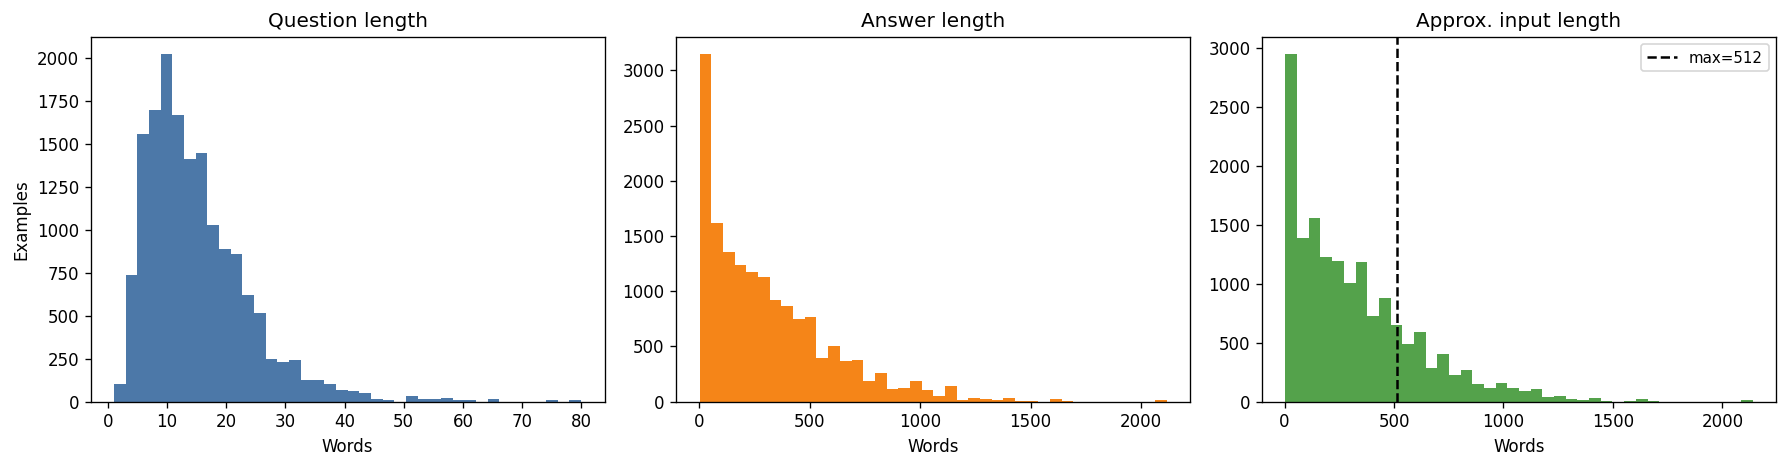

/tmp/ipykernel_3123497/4078723408.py:80: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, vert=False, showfliers=False)


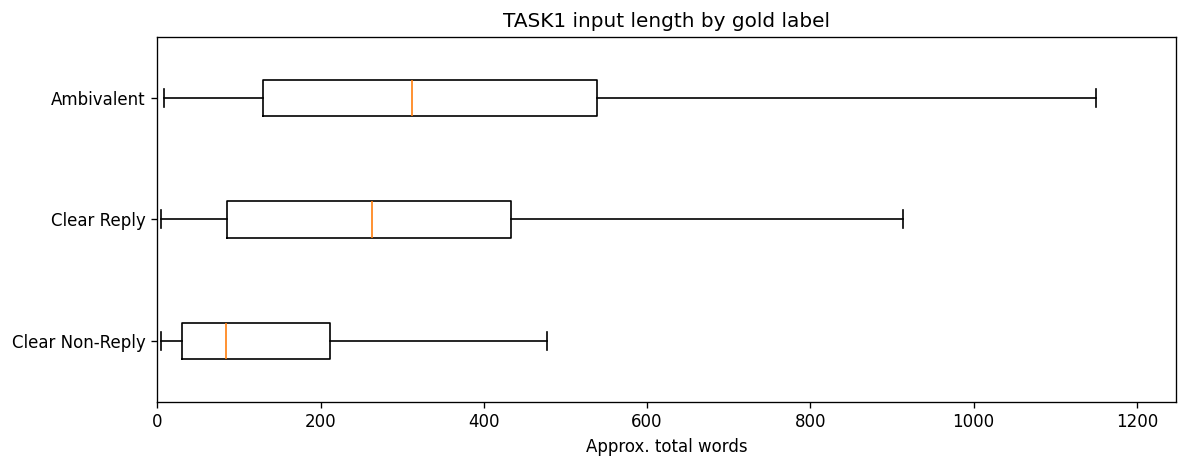

/tmp/ipykernel_3123497/4078723408.py:80: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, vert=False, showfliers=False)


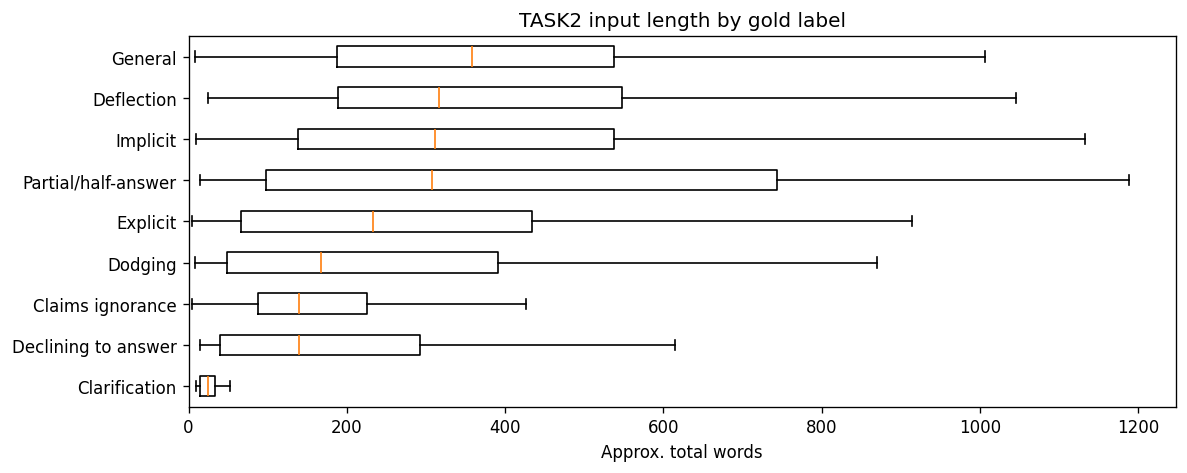

In [34]:
def save_figure(name: str) -> None:
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f"{name}.png", bbox_inches="tight")
    plt.savefig(FIGURE_DIR / f"{name}.pdf", bbox_inches="tight")
    plt.show()


if analysis_examples.empty:
    warn("Length/truncation analysis skipped.")
else:
    length_stats = analysis_examples.groupby(["task", "split"], dropna=False).agg(
        examples=("example_id_std", "count"),
        question_words_mean=("question_words", "mean"),
        question_words_median=("question_words", "median"),
        answer_words_mean=("answer_words", "mean"),
        answer_words_median=("answer_words", "median"),
        total_words_mean=("total_words", "mean"),
        total_words_p95=("total_words", lambda s: s.quantile(0.95)),
        likely_truncated_rate=("likely_truncated", "mean"),
        multipart_rate=("likely_multipart_question", "mean"),
    ).reset_index()
    length_stats.to_csv(TABLE_DIR / "length_statistics.csv", index=False)
    display(length_stats)

    if "gold" in analysis_examples:
        truncation_stats = analysis_examples.groupby(["task", "gold"], dropna=False).agg(
            examples=("example_id_std", "count"),
            total_words_mean=("total_words", "mean"),
            likely_truncated_rate=("likely_truncated", "mean"),
            accuracy=("correct", "mean"),
        ).reset_index()
        truncation_stats.to_csv(TABLE_DIR / "truncation_statistics.csv", index=False)
        display(truncation_stats)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].hist(analysis_examples["question_words"], bins=40, color="#4C78A8")
    axes[0].set_title("Question length")
    axes[0].set_xlabel("Words")
    axes[0].set_ylabel("Examples")
    axes[1].hist(analysis_examples["answer_words"], bins=40, color="#F58518")
    axes[1].set_title("Answer length")
    axes[1].set_xlabel("Words")
    axes[2].hist(analysis_examples["total_words"], bins=40, color="#54A24B")
    axes[2].axvline(MAX_SEQUENCE_LENGTH, color="black", linestyle="--", label=f"max={MAX_SEQUENCE_LENGTH}")
    axes[2].set_title("Approx. input length")
    axes[2].set_xlabel("Words")
    axes[2].legend()
    save_figure("length_distributions")

    if "gold" in analysis_examples and analysis_examples["gold"].notna().any():
        max_total_words = analysis_examples.loc[
            analysis_examples["gold"].notna(),
            "total_words",
        ].quantile(0.99)
    
        for task in ["task1", "task2"]:
            plot_data = analysis_examples[
                (analysis_examples["task"] == task)
                & analysis_examples["gold"].notna()
            ].copy()
    
            if plot_data.empty:
                warn(f"Input length by gold label skipped for {task}: no labeled examples.")
                continue
    
            labels = (
                plot_data.groupby("gold")["total_words"]
                .median()
                .sort_values()
                .index
                .tolist()
            )
    
            data = [
                plot_data.loc[plot_data["gold"] == label, "total_words"].values
                for label in labels
            ]
    
            plt.figure(figsize=(10, max(4, 0.45 * len(labels))))
            plt.boxplot(data, labels=labels, vert=False, showfliers=False)
            plt.xlim(0, max_total_words)
            plt.xlabel("Approx. total words")
            plt.title(f"{task.upper()} input length by gold label")
            save_figure(f"input_length_by_label_{task}")

## 8. Metric Functions

Macro-F1 is the main metric. Bootstrap confidence intervals are computed over examples, which is appropriate even when seed ensembles were not run.

In [35]:
def labels_for_task(task: str, *values) -> list[str]:
    observed = set()
    for value in values:
        if isinstance(value, pd.Series):
            observed.update(value.dropna().astype(str).tolist())
        elif isinstance(value, (list, tuple, np.ndarray)):
            observed.update([str(v) for v in value if pd.notna(v)])
    if task == "task1":
        extras = sorted(observed.difference(TASK1_LABELS))
        return TASK1_LABELS + extras
    if task == "task2":
        extras = sorted(observed.difference(TASK2_LABELS))
        return TASK2_LABELS + extras
    return sorted(observed)


def bootstrap_macro_f1(y_true, y_pred, labels, n_boot=1000, seed=RANDOM_SEED):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    if len(y_true) == 0:
        return np.nan, np.nan
    local_rng = np.random.default_rng(seed)
    scores = []
    indices = np.arange(len(y_true))
    for _ in range(n_boot):
        sample = local_rng.choice(indices, size=len(indices), replace=True)
        scores.append(f1_score(y_true[sample], y_pred[sample], labels=labels, average="macro", zero_division=0))
    return float(np.percentile(scores, 2.5)), float(np.percentile(scores, 97.5))


def paired_bootstrap_delta(y_true, pred_a, pred_b, labels, n_boot=1000, seed=RANDOM_SEED):
    y_true = np.asarray(y_true)
    pred_a = np.asarray(pred_a)
    pred_b = np.asarray(pred_b)
    if len(y_true) == 0:
        return np.nan, np.nan, np.nan
    local_rng = np.random.default_rng(seed)
    indices = np.arange(len(y_true))
    deltas = []
    for _ in range(n_boot):
        sample = local_rng.choice(indices, size=len(indices), replace=True)
        score_a = f1_score(y_true[sample], pred_a[sample], labels=labels, average="macro", zero_division=0)
        score_b = f1_score(y_true[sample], pred_b[sample], labels=labels, average="macro", zero_division=0)
        deltas.append(score_a - score_b)
    return float(np.mean(deltas)), float(np.percentile(deltas, 2.5)), float(np.percentile(deltas, 97.5))


def compute_metrics_table(df: pd.DataFrame, n_boot=1000) -> tuple[pd.DataFrame, pd.DataFrame]:
    metric_rows = []
    per_class_rows = []
    if df.empty:
        return pd.DataFrame(), pd.DataFrame()
    valid = df.dropna(subset=["gold", "prediction"]).copy()
    for keys, group in valid.groupby(["task", "split", "experiment", "source_file"], dropna=False):
        task, split, experiment, source_file = keys
        labels = labels_for_task(task, group["gold"], group["prediction"])
        y_true = group["gold"].tolist()
        y_pred = group["prediction"].tolist()
        ci_low, ci_high = bootstrap_macro_f1(y_true, y_pred, labels, n_boot=n_boot)
        metric_rows.append({
            "task": task,
            "split": split,
            "experiment": experiment,
            "source_file": source_file,
            "n_examples": len(group),
            "macro_f1": f1_score(y_true, y_pred, labels=labels, average="macro", zero_division=0),
            "macro_f1_ci_low": ci_low,
            "macro_f1_ci_high": ci_high,
            "weighted_f1": f1_score(y_true, y_pred, labels=labels, average="weighted", zero_division=0),
            "accuracy": accuracy_score(y_true, y_pred),
        })
        report = classification_report(y_true, y_pred, labels=labels, output_dict=True, zero_division=0)
        for label in labels:
            values = report.get(label, {})
            per_class_rows.append({
                "task": task,
                "split": split,
                "experiment": experiment,
                "source_file": source_file,
                "label": label,
                "precision": values.get("precision", np.nan),
                "recall": values.get("recall", np.nan),
                "f1": values.get("f1-score", np.nan),
                "support": values.get("support", np.nan),
            })
    return pd.DataFrame(metric_rows), pd.DataFrame(per_class_rows)

## 9. Main Results

The result tables are computed from prediction files with both gold labels and predictions. For Task 2 test predictions, `majority_label` is treated as the gold label when available.

In [36]:
def short_experiment_name(name):
    raw = str(name)
    s = raw.lower()
    normalized = s.replace("-", "_")

    if "politician_answer" in normalized:
        return "DeBERTa-v3-base + alt input"
    if "weighted" in normalized:
        return "DeBERTa-v3-base + weighted"
    if "multitask" in normalized or "multi_task" in normalized:
        return "DeBERTa-v3-base multi-task"
    if "deberta_xlarge" in normalized:
        return "DeBERTa-xlarge"
    if "deberta_v3_large" in normalized:
        return "DeBERTa-v3-large"
    if "deberta_v3_base" in normalized:
        return "DeBERTa-v3-base"
    if "roberta_large" in normalized:
        return "RoBERTa-large"
    if "bert_base" in normalized or "bert_base_uncased" in normalized:
        return "BERT-base"
    return raw

,task,split,experiment,n_examples,macro_f1,macro_f1_ci_low,macro_f1_ci_high,weighted_f1,accuracy
5,task1,dev,DeBERTa-v3-large,690,0.690275,0.643525,0.727670,0.721328,0.726087
6,task1,dev,DeBERTa-xlarge,690,0.686600,0.646189,0.724905,0.728819,0.730435
7,task1,dev,RoBERTa-large,690,0.676774,0.633013,0.715049,0.708981,0.711594
1,task1,dev,DeBERTa-v3-base multi-task,690,0.676042,0.632176,0.714579,0.708499,0.707246
3,task1,dev,DeBERTa-v3-base + alt input,690,0.671444,0.630516,0.710309,0.704056,0.705797
2,task1,dev,DeBERTa-v3-base,690,0.663508,0.619435,0.705302,0.696143,0.698551
4,task1,dev,DeBERTa-v3-base + weighted,690,0.630792,0.589295,0.672855,0.654279,0.659420
0,task1,dev,BERT-base,690,0.575503,0.530939,0.618706,0.630544,0.646377
14,task1,test,DeBERTa-xlarge,308,0.631590,0.554152,0.692156,0.700980,0.694805
10,task1,test,DeBERTa-v3-base,308,0.604594,0.534292,0.668708,0.688363,0.688312


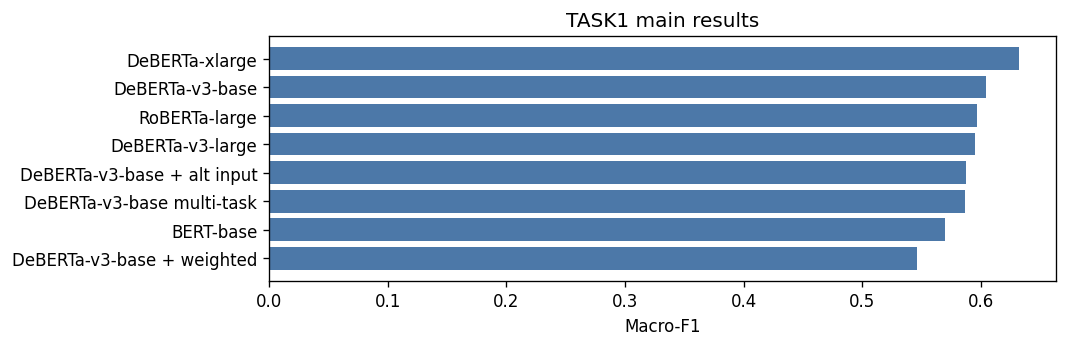

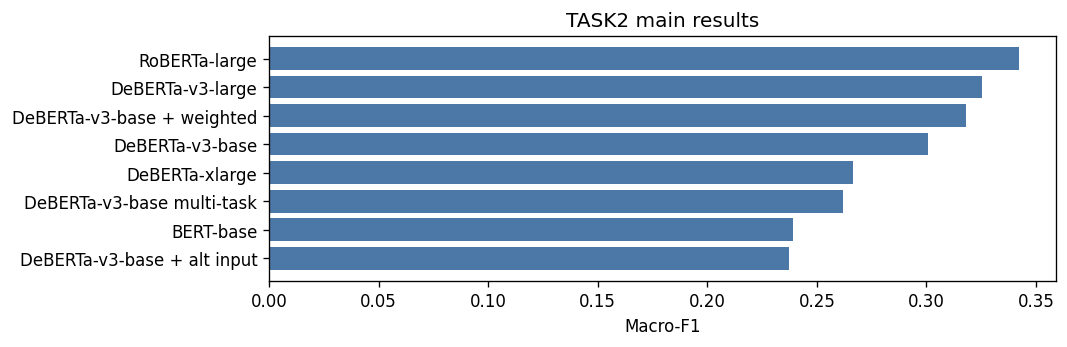

In [37]:
metric_results, per_class_results = compute_metrics_table(predictions, n_boot=500)

if not metric_results.empty:
    metric_results["raw_experiment"] = metric_results["experiment"]
    metric_results["experiment"] = metric_results["raw_experiment"].map(short_experiment_name)

if not per_class_results.empty:
    per_class_results["raw_experiment"] = per_class_results["experiment"]
    per_class_results["experiment"] = per_class_results["raw_experiment"].map(short_experiment_name)

if metric_results.empty:
    warn("Main result analysis skipped because no prediction file had both gold and prediction labels.")
else:
    task1_results = metric_results[metric_results["task"] == "task1"].sort_values("macro_f1", ascending=False)
    task2_results = metric_results[metric_results["task"] == "task2"].sort_values("macro_f1", ascending=False)
    task1_results.to_csv(TABLE_DIR / "main_results_task1.csv", index=False)
    task2_results.to_csv(TABLE_DIR / "main_results_task2.csv", index=False)
    compact = metric_results.sort_values(["task", "split", "macro_f1"], ascending=[True, True, False])
    compact.to_csv(TABLE_DIR / "compact_paper_results.csv", index=False)
    display(compact[["task", "split", "experiment", "n_examples", "macro_f1", "macro_f1_ci_low", "macro_f1_ci_high", "weighted_f1", "accuracy"]].head(80))

    for task, data, filename in [
        ("task1", task1_results, "main_results_task1"),
        ("task2", task2_results, "main_results_task2"),
    ]:
        if data.empty:
            continue
        plot_source = data[data["split"] == "test"] if (data["split"] == "test").any() else data
        top = plot_source.head(12).iloc[::-1]
        plt.figure(figsize=(9, max(3, 0.35 * len(top))))
        plt.barh(top["experiment"], top["macro_f1"], color="#4C78A8")
        plt.xlabel("Macro-F1")
        plt.title(f"{task.upper()} main results")
        save_figure(filename)

## 10. Task 2 Annotator Disagreement Analysis

This section runs only when multiple annotator columns or majority/unanimous labels are present.

,experiment,examples,majority_examples,unanimous_examples,no_majority_examples,majority_macro_f1,unanimous_macro_f1,any_annotator_match_rate
7,RoBERTa-large,308,275,125,33,0.342051,0.401895,0.525974
5,DeBERTa-v3-large,308,275,125,33,0.325411,0.386694,0.542208
4,DeBERTa-v3-base + weighted,308,275,125,33,0.318143,0.426081,0.373377
2,DeBERTa-v3-base,308,275,125,33,0.300936,0.387073,0.525974
6,DeBERTa-xlarge,308,275,125,33,0.266709,0.322959,0.529221
1,DeBERTa-v3-base multi-task,308,275,125,33,0.262020,0.309193,0.538961
0,BERT-base,308,275,125,33,0.239178,0.314095,0.412338
3,DeBERTa-v3-base + alt input,308,275,125,33,0.237514,0.285366,0.509740


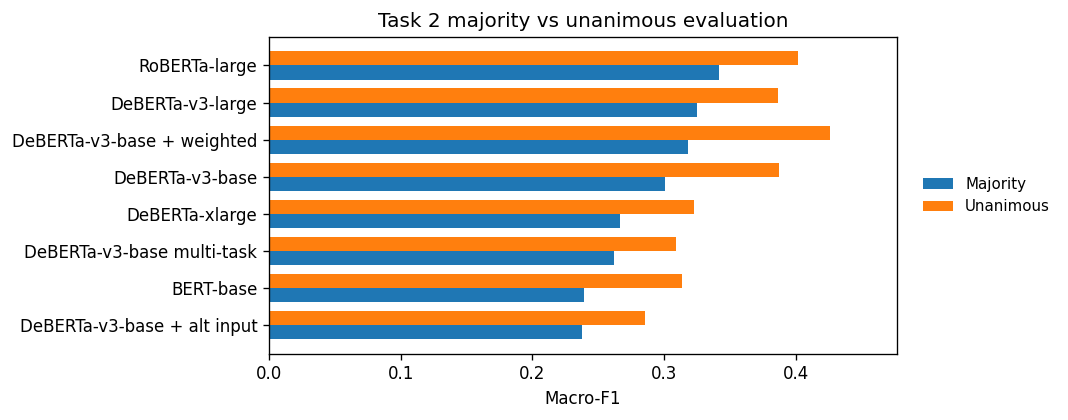

In [38]:
def majority_vote(values):
    clean = [normalize_label(v, "task2") for v in values if pd.notna(v) and str(v).strip()]
    counts = Counter(clean)
    for label, count in counts.most_common():
        if count >= 2:
            return label
    return np.nan


def unanimous_vote(values):
    clean = [normalize_label(v, "task2") for v in values if pd.notna(v) and str(v).strip()]
    return clean[0] if len(clean) == 3 and len(set(clean)) == 1 else np.nan


annotator_cols = [col for col in ANNOTATOR_CANDIDATES if col in predictions.columns]
if predictions.empty or len(annotator_cols) < 2:
    warn("Annotator disagreement analysis skipped because no multiple-annotator label columns were found.")
else:
    task2_test = predictions[(predictions["task"] == "task2") & (predictions["split"] == "test")].copy()
    if task2_test.empty:
        warn("Annotator disagreement analysis skipped because no Task 2 test predictions were found.")
    else:
        if "majority_label" not in task2_test.columns:
            task2_test["majority_label"] = task2_test[annotator_cols].apply(majority_vote, axis=1)
        if "unanimous_label" not in task2_test.columns:
            task2_test["unanimous_label"] = task2_test[annotator_cols].apply(unanimous_vote, axis=1)

        task2_test["has_majority"] = task2_test["majority_label"].notna()
        task2_test["has_unanimous"] = task2_test["unanimous_label"].notna()
        task2_test["any_annotator_match"] = task2_test.apply(
            lambda row: row["prediction"] in [
                normalize_label(row[c], "task2")
                for c in annotator_cols
                if c in row and pd.notna(row[c])
            ],
            axis=1,
        )

        rows = []
        for experiment, group in task2_test.groupby("experiment"):
            majority = group[group["has_majority"]].copy()
            unanimous = group[group["has_unanimous"]].copy()

            maj_labels = (
                sorted(pd.unique(pd.concat([majority["majority_label"], majority["prediction"]]).dropna()))
                if not majority.empty
                else []
            )
            uni_labels = (
                sorted(pd.unique(pd.concat([unanimous["unanimous_label"], unanimous["prediction"]]).dropna()))
                if not unanimous.empty
                else []
            )

            rows.append({
                "experiment": short_experiment_name(experiment),
                "examples": len(group),
                "majority_examples": len(majority),
                "unanimous_examples": len(unanimous),
                "no_majority_examples": int((~group["has_majority"]).sum()),
                "majority_macro_f1": (
                    f1_score(
                        majority["majority_label"],
                        majority["prediction"],
                        labels=maj_labels,
                        average="macro",
                        zero_division=0,
                    )
                    if maj_labels
                    else np.nan
                ),
                "unanimous_macro_f1": (
                    f1_score(
                        unanimous["unanimous_label"],
                        unanimous["prediction"],
                        labels=uni_labels,
                        average="macro",
                        zero_division=0,
                    )
                    if uni_labels
                    else np.nan
                ),
                "any_annotator_match_rate": group["any_annotator_match"].mean(),
            })

        disagreement_stats = pd.DataFrame(rows).sort_values("majority_macro_f1", ascending=False)
        disagreement_stats.to_csv(TABLE_DIR / "annotator_disagreement_statistics.csv", index=False)
        display(disagreement_stats)


        plot_data = disagreement_stats.head(12).iloc[::-1].copy()
        
        y = np.arange(len(plot_data))
        bar_height = 0.38
        
        fig, ax = plt.subplots(figsize=(9, max(3, 0.45 * len(plot_data))))
        
        ax.barh(
            y - bar_height / 2,
            plot_data["majority_macro_f1"],
            height=bar_height,
            label="Majority",
        )
        
        ax.barh(
            y + bar_height / 2,
            plot_data["unanimous_macro_f1"],
            height=bar_height,
            label="Unanimous",
        )
        
        ax.set_yticks(y)
        ax.set_yticklabels(plot_data["experiment"])
        
        ax.set_xlabel("Macro-F1")
        ax.set_title("Task 2 majority vs unanimous evaluation")
        
        ax.set_xlim(
            0,
            max(
                plot_data[["majority_macro_f1", "unanimous_macro_f1"]].max().max() * 1.12,
                0.05,
            ),
        )
        
        # Put legend outside the plotting area
        ax.legend(
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
            frameon=False,
            fontsize=9,
        )
        
        plt.tight_layout()
        save_figure("task2_majority_vs_unanimous")

## 11. Ablation Analysis

Ablations are inferred conservatively from experiment names and config snapshots. Missing experiment families are skipped rather than described.

In [39]:
def ablation_family(experiment: str) -> str:
    name = str(experiment).lower().replace("-", "_")
    if "weighted" in name:
        return "class_weighted_loss"
    if "politician_answer" in name or "alt input" in name:
        return "input_format_politician_answer"
    if "multitask" in name or "multi_task" in name:
        return "multitask"
    if "bert_base" in name or "bert_base_uncased" in name:
        return "bert_base"
    if "roberta_large" in name:
        return "roberta_large"
    if "deberta_v3_large" in name:
        return "deberta_v3_large"
    if "deberta_xlarge" in name:
        return "deberta_xlarge"
    if "deberta_v3_base" in name:
        return "deberta_v3_base"
    return "other"


if metric_results.empty:
    warn("Ablation analysis skipped.")
else:
    ablations = metric_results.copy()
    family_source = "raw_experiment" if "raw_experiment" in ablations.columns else "experiment"
    ablations["ablation_family"] = ablations[family_source].map(ablation_family)
    ablation_summary = ablations.groupby(["task", "split", "ablation_family"], dropna=False).agg(
        best_macro_f1=("macro_f1", "max"),
        mean_macro_f1=("macro_f1", "mean"),
        runs=("source_file", "nunique"),
    ).reset_index().sort_values(["task", "split", "best_macro_f1"], ascending=[True, True, False])
    ablation_summary.to_csv(TABLE_DIR / "ablation_results.csv", index=False)
    display(ablation_summary)

,task,split,ablation_family,best_macro_f1,mean_macro_f1,runs
3,task1,dev,deberta_v3_large,0.690275,0.690275,1
4,task1,dev,deberta_xlarge,0.686600,0.686600,1
7,task1,dev,roberta_large,0.676774,0.676774,1
6,task1,dev,multitask,0.676042,0.676042,1
5,task1,dev,input_format_politician_answer,0.671444,0.671444,1
2,task1,dev,deberta_v3_base,0.663508,0.663508,1
1,task1,dev,class_weighted_loss,0.630792,0.630792,1
0,task1,dev,bert_base,0.575503,0.575503,1
12,task1,test,deberta_xlarge,0.631590,0.631590,1
10,task1,test,deberta_v3_base,0.604594,0.604594,1


## 12. Per-Class and Confusion Analysis

For each task, this section selects the best available system by macro-F1 and exports per-class reports, raw confusion matrices, normalized confusion matrices, and top confusion pairs.

,task,split,experiment,source_file,label,precision,recall,f1,support,raw_experiment
44,task1,test,DeBERTa-xlarge,outputs/runs/task1/deberta_xlarge_task1_microsoft_deberta_xlarge_task1_seed42_20260617_005356/artifacts/test_predictions.csv,Clear Non-Reply,0.541667,0.565217,0.553191,23.0,deberta_xlarge_task1_microsoft_deberta_xlarge_task1_seed42_20260617_005356
42,task1,test,DeBERTa-xlarge,outputs/runs/task1/deberta_xlarge_task1_microsoft_deberta_xlarge_task1_seed42_20260617_005356/artifacts/test_predictions.csv,Clear Reply,0.520408,0.645570,0.576271,79.0,deberta_xlarge_task1_microsoft_deberta_xlarge_task1_seed42_20260617_005356
43,task1,test,DeBERTa-xlarge,outputs/runs/task1/deberta_xlarge_task1_microsoft_deberta_xlarge_task1_seed42_20260617_005356/artifacts/test_predictions.csv,Ambivalent,0.806452,0.728155,0.765306,206.0,deberta_xlarge_task1_microsoft_deberta_xlarge_task1_seed42_20260617_005356


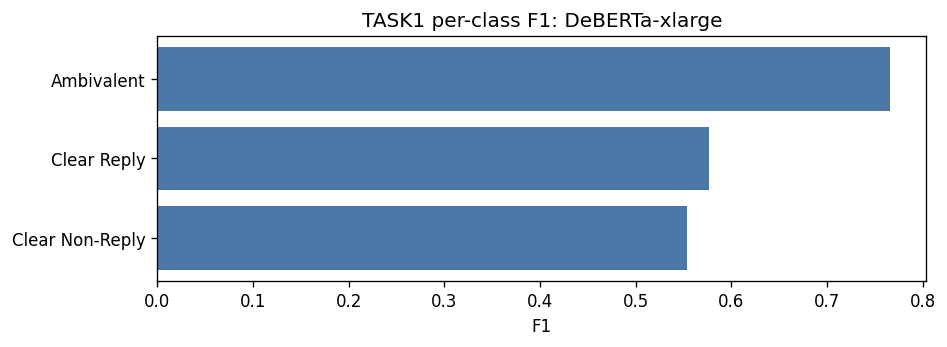

,gold_label,predicted_label,count,percent_of_gold_class
2,Ambivalent,Clear Reply,47,0.228155
0,Clear Reply,Ambivalent,26,0.329114
4,Clear Non-Reply,Ambivalent,10,0.434783
3,Ambivalent,Clear Non-Reply,9,0.043689
1,Clear Reply,Clear Non-Reply,2,0.025316


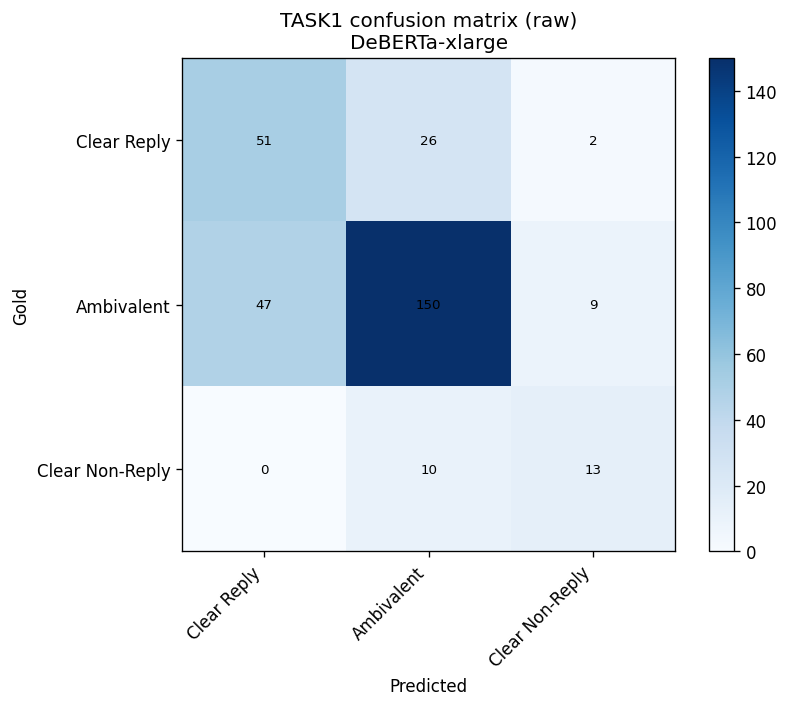

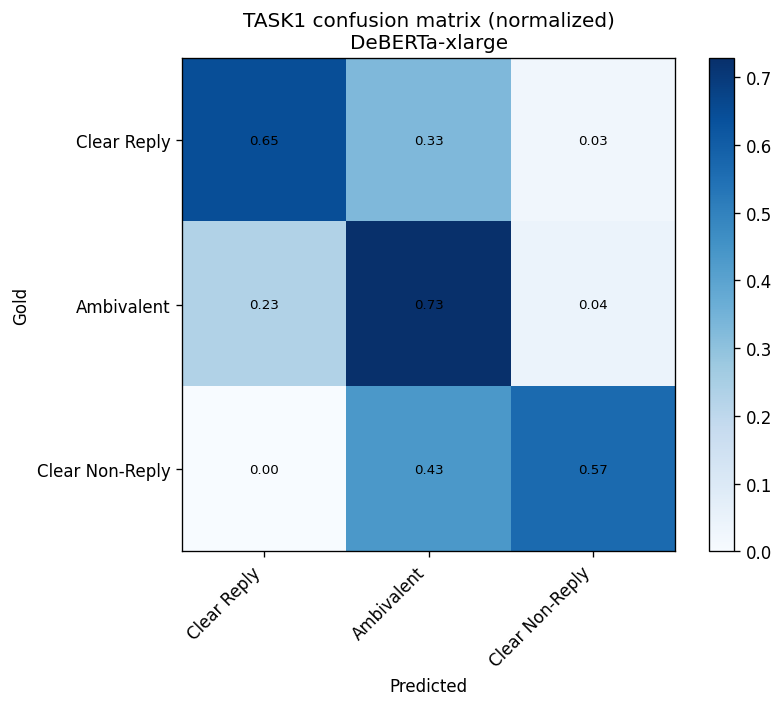

,task,split,experiment,source_file,label,precision,recall,f1,support,raw_experiment
188,task2,test,RoBERTa-large,outputs/runs/task2/roberta_large_task2_roberta_large_task2_seed42_20260617_004218/artifacts/test_predictions.csv,Partial/half-answer,0.000000,0.000000,0.000000,3.0,roberta_large_task2_roberta_large_task2_seed42_20260617_004218
184,task2,test,RoBERTa-large,outputs/runs/task2/roberta_large_task2_roberta_large_task2_seed42_20260617_004218/artifacts/test_predictions.csv,Implicit,0.227273,0.087719,0.126582,57.0,roberta_large_task2_roberta_large_task2_seed42_20260617_004218
186,task2,test,RoBERTa-large,outputs/runs/task2/roberta_large_task2_roberta_large_task2_seed42_20260617_004218/artifacts/test_predictions.csv,General,0.333333,0.083333,0.133333,48.0,roberta_large_task2_roberta_large_task2_seed42_20260617_004218
187,task2,test,RoBERTa-large,outputs/runs/task2/roberta_large_task2_roberta_large_task2_seed42_20260617_004218/artifacts/test_predictions.csv,Deflection,0.250000,0.176471,0.206897,17.0,roberta_large_task2_roberta_large_task2_seed42_20260617_004218
189,task2,test,RoBERTa-large,outputs/runs/task2/roberta_large_task2_roberta_large_task2_seed42_20260617_004218/artifacts/test_predictions.csv,Declining to answer,0.363636,0.363636,0.363636,11.0,roberta_large_task2_roberta_large_task2_seed42_20260617_004218
185,task2,test,RoBERTa-large,outputs/runs/task2/roberta_large_task2_roberta_large_task2_seed42_20260617_004218/artifacts/test_predictions.csv,Dodging,0.285714,0.520000,0.368794,50.0,roberta_large_task2_roberta_large_task2_seed42_20260617_004218
190,task2,test,RoBERTa-large,outputs/runs/task2/roberta_large_task2_roberta_large_task2_seed42_20260617_004218/artifacts/test_predictions.csv,Claims ignorance,0.312500,0.625000,0.416667,8.0,roberta_large_task2_roberta_large_task2_seed42_20260617_004218
183,task2,test,RoBERTa-large,outputs/runs/task2/roberta_large_task2_roberta_large_task2_seed42_20260617_004218/artifacts/test_predictions.csv,Explicit,0.518519,0.727273,0.605405,77.0,roberta_large_task2_roberta_large_task2_seed42_20260617_004218
191,task2,test,RoBERTa-large,outputs/runs/task2/roberta_large_task2_roberta_large_task2_seed42_20260617_004218/artifacts/test_predictions.csv,Clarification,1.000000,0.750000,0.857143,4.0,roberta_large_task2_roberta_large_task2_seed42_20260617_004218


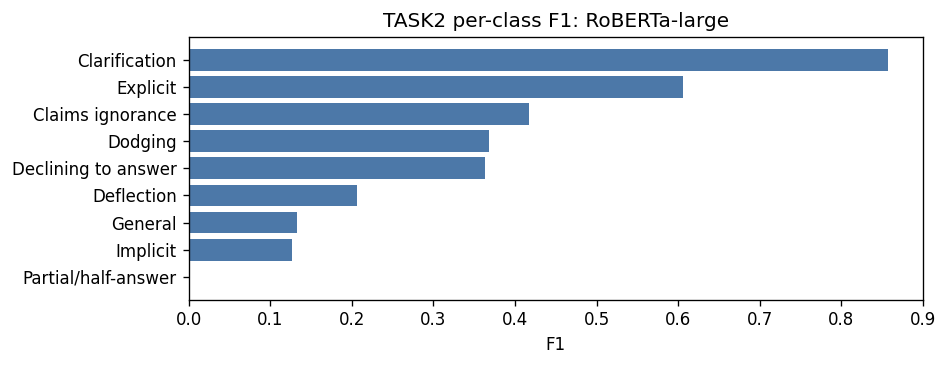

,gold_label,predicted_label,count,percent_of_gold_class
5,Implicit,Explicit,26,0.456140
6,Implicit,Dodging,22,0.385965
17,General,Dodging,20,0.416667
15,General,Explicit,17,0.354167
1,Explicit,Dodging,11,0.142857
14,Dodging,Claims ignorance,6,0.120000
0,Explicit,Implicit,6,0.077922
22,Deflection,Dodging,6,0.352941
10,Dodging,Implicit,5,0.100000
13,Dodging,Declining to answer,5,0.100000


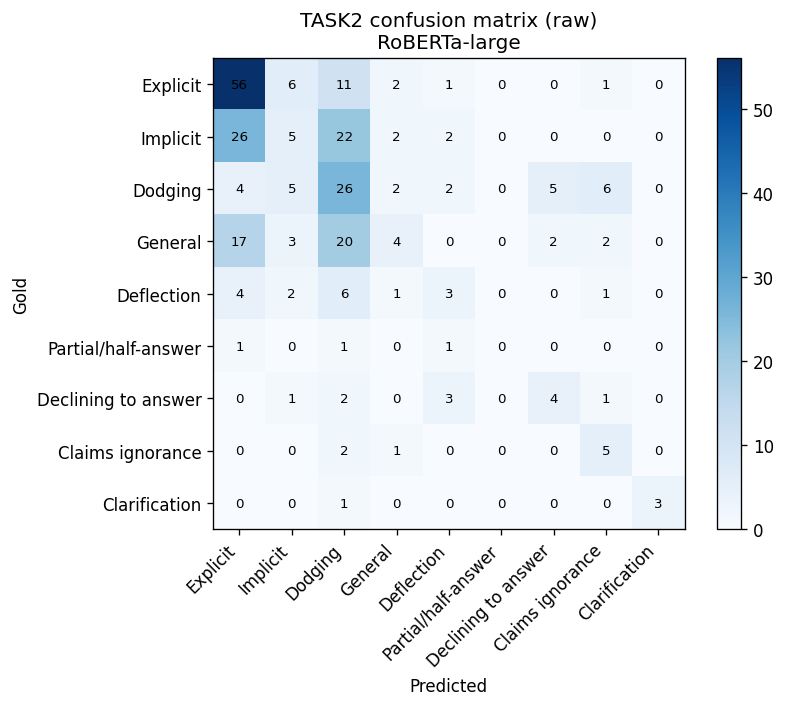

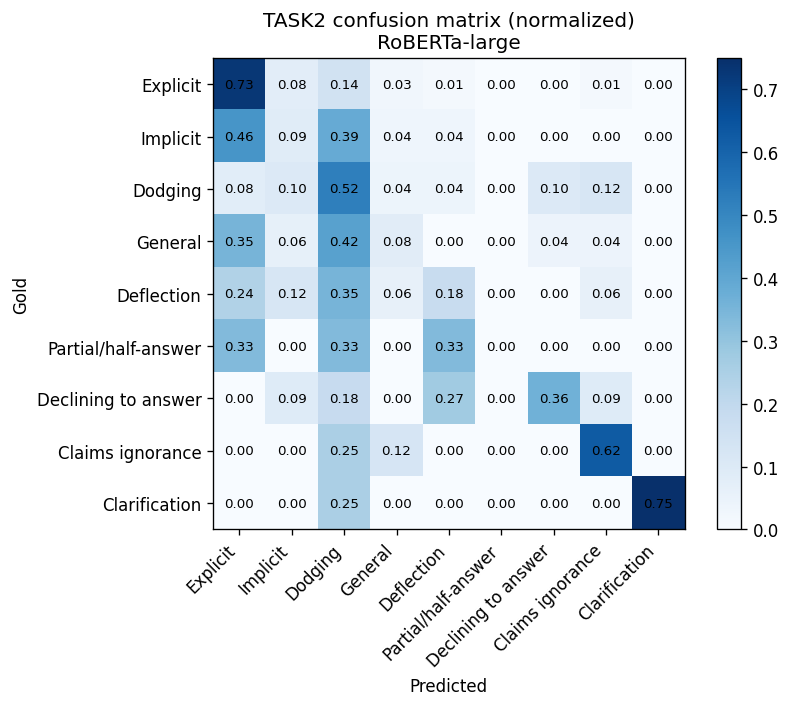

In [40]:
def best_system_for_task(task: str, preferred_split: str = "test"):
    if metric_results.empty:
        return None
    subset = metric_results[metric_results["task"] == task].copy()
    if subset.empty:
        return None
    preferred = subset[subset["split"] == preferred_split]
    if not preferred.empty:
        subset = preferred
    subset = subset.sort_values("macro_f1", ascending=False)
    return subset.iloc[0] if not subset.empty else None


def top_confusions(y_true, y_pred, labels):
    matrix = confusion_matrix(y_true, y_pred, labels=labels)
    rows = []
    gold_counts = matrix.sum(axis=1)
    for i, gold in enumerate(labels):
        for j, pred in enumerate(labels):
            if i == j:
                continue
            count = int(matrix[i, j])
            if count:
                rows.append({
                    "gold_label": gold,
                    "predicted_label": pred,
                    "count": count,
                    "percent_of_gold_class": count / gold_counts[i] if gold_counts[i] else np.nan,
                })
    return pd.DataFrame(rows).sort_values("count", ascending=False) if rows else pd.DataFrame(columns=["gold_label", "predicted_label", "count", "percent_of_gold_class"])


def plot_confusion_matrices(group: pd.DataFrame, task: str, experiment: str):
    labels = labels_for_task(task, group["gold"], group["prediction"])
    y_true = group["gold"].tolist()
    y_pred = group["prediction"].tolist()
    matrix = confusion_matrix(y_true, y_pred, labels=labels)
    normalized = matrix / np.maximum(matrix.sum(axis=1, keepdims=True), 1)
    title_name = short_experiment_name(experiment)

    for data, suffix, fmt in [(matrix, "raw", "d"), (normalized, "normalized", ".2f")]:
        fig, ax = plt.subplots(figsize=(8, 6))
        im = ax.imshow(data, cmap="Blues")
        ax.set_xticks(range(len(labels)), labels=labels, rotation=45, ha="right")
        ax.set_yticks(range(len(labels)), labels=labels)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Gold")
        ax.set_title(f"{task.upper()} confusion matrix ({suffix})\n{title_name}")
        for i in range(len(labels)):
            for j in range(len(labels)):
                ax.text(j, i, format(data[i, j], fmt), ha="center", va="center", fontsize=8)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        save_figure(f"confusion_matrix_{task}_{suffix}")


for task in ["task1", "task2"]:
    best = best_system_for_task(task)
    if best is None:
        warn(f"No best system found for {task}.")
        continue
    group = predictions[
        (predictions["task"] == task)
        & (predictions["source_file"] == best["source_file"])
        & predictions["gold"].notna()
        & predictions["prediction"].notna()
    ].copy()
    if group.empty:
        warn(f"Best-system rows missing for {task}.")
        continue
    task_per_class = per_class_results[
        (per_class_results["task"] == task)
        & (per_class_results["source_file"] == best["source_file"])
    ].sort_values("f1")
    task_per_class.to_csv(TABLE_DIR / f"per_class_report_{task}.csv", index=False)
    display(task_per_class)

    plt.figure(figsize=(8, max(3, 0.35 * len(task_per_class))))
    plt.barh(task_per_class["label"], task_per_class["f1"], color="#4C78A8")
    plt.xlabel("F1")
    plt.title(f"{task.upper()} per-class F1: {short_experiment_name(best['experiment'])}")
    save_figure(f"per_class_f1_{task}")

    labels = labels_for_task(task, group["gold"], group["prediction"])
    confusions = top_confusions(group["gold"], group["prediction"], labels)
    confusions.to_csv(TABLE_DIR / f"top_confusions_{task}.csv", index=False)
    display(confusions.head(20))
    plot_confusion_matrices(group, task, best["experiment"])

    if not confusions.empty:
        selected_errors = []
        for row in confusions.head(5).itertuples(index=False):
            subset = group[(group["gold"] == row.gold_label) & (group["prediction"] == row.predicted_label)].head(3)
            selected_errors.append(subset)
        error_examples = pd.concat(selected_errors) if selected_errors else pd.DataFrame()
        (EXAMPLE_DIR / f"common_error_examples_{task}.md").write_text(
            example_markdown(error_examples, f"Common {task.upper()} Error Examples", include_prediction=True),
            encoding="utf-8",
        )

## 13. Confidence and Calibration

Runs only when probability columns are available in prediction files.

,task,split,experiment,examples,mean_confidence,mean_confidence_correct,mean_confidence_wrong,mean_entropy,ece_10_bins
10,task1,test,deberta_v3_base_task1_microsoft_deberta_v3_base_task1_seed42_20260617_004551,308,0.752163,0.763899,0.726245,0.583720,0.085946
8,task1,test,bert_base_task1_bert_base_uncased_task1_seed42_20260617_004218,308,0.760398,0.769107,0.740872,0.567279,0.088937
2,task1,dev,deberta_v3_base_task1_microsoft_deberta_v3_base_task1_seed42_20260617_004551,690,0.787025,0.798661,0.760062,0.537741,0.103532
15,task1,test,roberta_large_task1_roberta_large_task1_seed42_20260617_004215,308,0.769626,0.792485,0.723458,0.525705,0.110462
3,task1,dev,deberta_v3_base_task1_politician_answer_microsoft_deberta_v3_base_task1_seed42_20260617_005355,690,0.807126,0.822967,0.769123,0.483957,0.110708
6,task1,dev,deberta_xlarge_task1_microsoft_deberta_xlarge_task1_seed42_20260617_005356,690,0.841235,0.860968,0.787763,0.424538,0.116311
7,task1,dev,roberta_large_task1_roberta_large_task1_seed42_20260617_004215,690,0.823023,0.841762,0.776786,0.434888,0.117272
4,task1,dev,deberta_v3_base_task1_weighted_microsoft_deberta_v3_base_task1_seed42_20260617_004953,690,0.662725,0.662966,0.662256,0.711317,0.119091
11,task1,test,deberta_v3_base_task1_politician_answer_microsoft_deberta_v3_base_task1_seed42_20260617_005355,308,0.775523,0.790217,0.744501,0.533448,0.123907
9,task1,test,deberta_v3_base_multitask_microsoft_deberta_v3_base_multitask_seed42_20260617_005757,308,0.815977,0.839039,0.765049,0.463225,0.127665


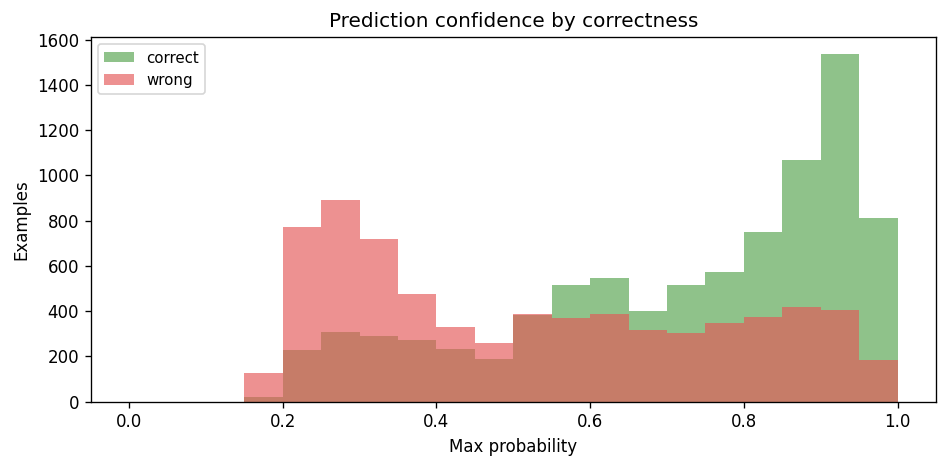

In [41]:
def entropy_from_probs(row, prob_cols):
    values = pd.to_numeric(row[prob_cols], errors="coerce").dropna().values.astype(float)
    values = values[values > 0]
    return float(-(values * np.log(values)).sum()) if len(values) else np.nan


def ece_score(confidence, correct, n_bins=10):
    confidence = np.asarray(confidence, dtype=float)
    correct = np.asarray(correct, dtype=float)
    mask = ~np.isnan(confidence) & ~np.isnan(correct)
    confidence = confidence[mask]
    correct = correct[mask]
    if len(confidence) == 0:
        return np.nan
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for lo, hi in zip(bins[:-1], bins[1:]):
        in_bin = (confidence > lo) & (confidence <= hi)
        if not in_bin.any():
            continue
        ece += in_bin.mean() * abs(correct[in_bin].mean() - confidence[in_bin].mean())
    return float(ece)


prob_cols_global = probability_columns(predictions) if not predictions.empty else []
if predictions.empty or not prob_cols_global:
    warn("Confidence/calibration analysis skipped because no probability columns were found.")
else:
    confidence_df = predictions.copy()
    confidence_df["entropy"] = confidence_df.apply(lambda row: entropy_from_probs(row, prob_cols_global), axis=1)
    rows = []
    for (task, split, experiment), group in confidence_df.dropna(subset=["confidence", "correct"]).groupby(["task", "split", "experiment"], dropna=False):
        rows.append({
            "task": task,
            "split": split,
            "experiment": experiment,
            "examples": len(group),
            "mean_confidence": group["confidence"].mean(),
            "mean_confidence_correct": group.loc[group["correct"] == True, "confidence"].mean(),
            "mean_confidence_wrong": group.loc[group["correct"] == False, "confidence"].mean(),
            "mean_entropy": group["entropy"].mean(),
            "ece_10_bins": ece_score(group["confidence"], group["correct"], n_bins=10),
        })
    confidence_stats = pd.DataFrame(rows).sort_values(["task", "ece_10_bins"])
    confidence_stats.to_csv(TABLE_DIR / "confidence_statistics.csv", index=False)
    display(confidence_stats)

    high_conf_wrong = confidence_df[(confidence_df["correct"] == False) & (confidence_df["confidence"] >= 0.8)].sort_values("confidence", ascending=False).head(30)
    (EXAMPLE_DIR / "high_confidence_wrong_examples.md").write_text(
        example_markdown(high_conf_wrong, "High-Confidence Wrong Examples", include_prediction=True),
        encoding="utf-8",
    )

    plt.figure(figsize=(8, 4))
    bins = np.linspace(0, 1, 21)
    plt.hist(confidence_df.loc[confidence_df["correct"] == True, "confidence"].dropna(), bins=bins, alpha=0.65, label="correct", color="#54A24B")
    plt.hist(confidence_df.loc[confidence_df["correct"] == False, "confidence"].dropna(), bins=bins, alpha=0.65, label="wrong", color="#E45756")
    plt.xlabel("Max probability")
    plt.ylabel("Examples")
    plt.title("Prediction confidence by correctness")
    plt.legend()
    save_figure("confidence_by_correctness")

## 14. Metadata and Length Difficulty Analysis

This section checks whether long, likely truncated, multi-part, or metadata-defined subsets are harder. It uses simple heuristics and skips unavailable metadata.

In [42]:
if analysis_examples.empty or "correct" not in analysis_examples:
    warn("Metadata/length difficulty analysis skipped.")
else:
    difficulty_rows = []
    subset_specs = [
        ("likely_truncated", analysis_examples["likely_truncated"]),
        ("not_truncated", ~analysis_examples["likely_truncated"]),
        ("likely_multipart_question", analysis_examples["likely_multipart_question"]),
        ("not_multipart_question", ~analysis_examples["likely_multipart_question"]),
        ("answer_length_top_quartile", analysis_examples["answer_words"] >= analysis_examples["answer_words"].quantile(0.75)),
        ("answer_length_bottom_quartile", analysis_examples["answer_words"] <= analysis_examples["answer_words"].quantile(0.25)),
    ]
    for task in ["task1", "task2"]:
        task_df = analysis_examples[(analysis_examples["task"] == task) & analysis_examples["gold"].notna() & analysis_examples["prediction"].notna()]
        labels = sorted(pd.unique(pd.concat([task_df["gold"], task_df["prediction"]]).dropna())) if not task_df.empty else []
        for name, mask in subset_specs:
            group = task_df[mask.loc[task_df.index]]
            if group.empty or not labels:
                continue
            difficulty_rows.append({
                "task": task,
                "subset": name,
                "examples": len(group),
                "accuracy": group["correct"].mean(),
                "macro_f1": f1_score(group["gold"], group["prediction"], labels=labels, average="macro", zero_division=0),
            })
        for meta in ["president", "speaker", "source", "year"]:
            if meta not in task_df.columns:
                continue
            for value, group in task_df.groupby(meta):
                if len(group) < 10:
                    continue
                difficulty_rows.append({
                    "task": task,
                    "subset": f"{meta}={value}",
                    "examples": len(group),
                    "accuracy": group["correct"].mean(),
                    "macro_f1": f1_score(group["gold"], group["prediction"], labels=labels, average="macro", zero_division=0),
                })
    difficulty = pd.DataFrame(difficulty_rows).sort_values(["task", "macro_f1"], ascending=[True, True])
    difficulty.to_csv(TABLE_DIR / "metadata_and_length_performance.csv", index=False)
    display(difficulty.head(50))

,task,subset,examples,accuracy,macro_f1
9,task1,president=Joseph R. Biden,584,0.583904,0.478416
4,task1,answer_length_top_quartile,2064,0.723837,0.493246
0,task1,likely_truncated,1848,0.733225,0.502475
3,task1,not_multipart_question,6000,0.675000,0.632019
8,task1,president=George W. Bush,1328,0.670181,0.642565
1,task1,not_truncated,6136,0.681389,0.648512
7,task1,president=Donald J. Trump,1968,0.693089,0.678571
2,task1,likely_multipart_question,1984,0.748992,0.680508
6,task1,president=Barack Obama,1640,0.767683,0.692730
5,task1,answer_length_bottom_quartile,1984,0.700101,0.699312


## 15. Paired Bootstrap System Comparisons

When systems predict the same examples for the same task/split, paired bootstrap estimates whether the macro-F1 difference is stable.

In [43]:
comparison_rows = []
if predictions.empty:
    warn("Paired bootstrap comparisons skipped.")
else:
    for (task, split), group in predictions.dropna(subset=["gold", "prediction"]).groupby(["task", "split"], dropna=False):
        systems = {}
        for experiment, exp_group in group.groupby("experiment"):
            key_cols = ["example_id_std"]
            dedup = exp_group.drop_duplicates(key_cols)
            systems[experiment] = dedup.set_index("example_id_std")[["gold", "prediction"]]
        system_names = list(systems)
        for i, name_a in enumerate(system_names):
            for name_b in system_names[i + 1:]:
                merged = systems[name_a].join(systems[name_b], how="inner", lsuffix="_a", rsuffix="_b")
                if len(merged) < 20:
                    continue
                if not (merged["gold_a"] == merged["gold_b"]).all():
                    continue
                labels = labels_for_task(task, merged["gold_a"], merged["prediction_a"], merged["prediction_b"])
                delta, low, high = paired_bootstrap_delta(
                    merged["gold_a"].values,
                    merged["prediction_a"].values,
                    merged["prediction_b"].values,
                    labels,
                    n_boot=500,
                )
                comparison_rows.append({
                    "task": task,
                    "split": split,
                    "system_a": name_a,
                    "system_b": name_b,
                    "shared_examples": len(merged),
                    "macro_f1_delta_a_minus_b": delta,
                    "ci_low": low,
                    "ci_high": high,
                })
comparisons = pd.DataFrame(comparison_rows)
if comparisons.empty:
    warn("No paired system comparisons were possible.")
else:
    comparisons.to_csv(TABLE_DIR / "paired_bootstrap_comparisons.csv", index=False)
    display(comparisons.sort_values(["task", "macro_f1_delta_a_minus_b"], ascending=[True, False]).head(50))

,task,split,system_a,system_b,shared_examples,macro_f1_delta_a_minus_b,ci_low,ci_high
42,task1,test,deberta_v3_base_task1_microsoft_deberta_v3_base_task1_seed42_20260617_004551,deberta_v3_base_task1_weighted_microsoft_deberta_v3_base_task1_seed42_20260617_004953,308,0.057675,0.005070,0.122522
9,task1,dev,deberta_v3_base_multitask_microsoft_deberta_v3_base_multitask_seed42_20260617_005757,deberta_v3_base_task1_weighted_microsoft_deberta_v3_base_task1_seed42_20260617_004953,690,0.046267,0.007614,0.081832
18,task1,dev,deberta_v3_base_task1_politician_answer_microsoft_deberta_v3_base_task1_seed42_20260617_005355,deberta_v3_base_task1_weighted_microsoft_deberta_v3_base_task1_seed42_20260617_004953,690,0.041516,0.007987,0.074064
46,task1,test,deberta_v3_base_task1_politician_answer_microsoft_deberta_v3_base_task1_seed42_20260617_005355,deberta_v3_base_task1_weighted_microsoft_deberta_v3_base_task1_seed42_20260617_004953,308,0.039611,-0.018095,0.101266
37,task1,test,deberta_v3_base_multitask_microsoft_deberta_v3_base_multitask_seed42_20260617_005757,deberta_v3_base_task1_weighted_microsoft_deberta_v3_base_task1_seed42_20260617_004953,308,0.039095,-0.041643,0.117400
55,task1,test,deberta_xlarge_task1_microsoft_deberta_xlarge_task1_seed42_20260617_005356,roberta_large_task1_roberta_large_task1_seed42_20260617_004215,308,0.036265,-0.034045,0.103749
14,task1,dev,deberta_v3_base_task1_microsoft_deberta_v3_base_task1_seed42_20260617_004551,deberta_v3_base_task1_weighted_microsoft_deberta_v3_base_task1_seed42_20260617_004953,690,0.034010,0.004558,0.066343
31,task1,test,bert_base_task1_bert_base_uncased_task1_seed42_20260617_004218,deberta_v3_base_task1_weighted_microsoft_deberta_v3_base_task1_seed42_20260617_004953,308,0.023139,-0.055361,0.095113
41,task1,test,deberta_v3_base_task1_microsoft_deberta_v3_base_task1_seed42_20260617_004551,deberta_v3_base_task1_politician_answer_microsoft_deberta_v3_base_task1_seed42_20260617_005355,308,0.018064,-0.027507,0.074983
26,task1,dev,deberta_v3_large_task1_microsoft_deberta_v3_large_task1_seed42_20260617_004218,roberta_large_task1_roberta_large_task1_seed42_20260617_004215,690,0.012322,-0.025353,0.045805


## 16. Paper Draft Generation

This creates a markdown draft using computed numbers only. It leaves placeholders where data are unavailable.

In [44]:
def best_row(task: str):
    if metric_results.empty:
        return None
    subset = metric_results[metric_results["task"] == task].sort_values("macro_f1", ascending=False)
    return subset.iloc[0] if not subset.empty else None


def fmt_score(value):
    return "N/A" if pd.isna(value) else f"{value:.3f}"


def draft_text():
    lines = ["# Paper Results Draft", ""]
    lines.append("## Dataset Analysis")
    if not dataset_statistics.empty:
        total_examples = int(dataset_statistics["num_examples"].sum())
        lines.append(f"The available analysis files contain {total_examples} example rows across detected task/split combinations.")
        if not label_dist_task1.empty:
            labels = ", ".join(f"{r.label} ({r.count})" for r in label_dist_task1.itertuples())
            lines.append(f"For Task 1, the observed label distribution is: {labels}.")
        if not label_dist_task2.empty:
            labels = ", ".join(f"{r.label} ({r.count})" for r in label_dist_task2.itertuples())
            lines.append(f"For Task 2, the observed label distribution is: {labels}.")
    else:
        lines.append("[Dataset statistics were unavailable because no usable data/prediction files were found.]")

    lines.append("")
    lines.append("## Experimental Setup")
    lines.append("We evaluate clarity classification and fine-grained evasion-strategy classification using macro-F1 as the primary metric. The notebook recomputes metrics from saved prediction files and uses bootstrap confidence intervals over examples.")

    lines.append("")
    lines.append("## Main Results")
    for task in ["task1", "task2"]:
        row = best_row(task)
        if row is None:
            lines.append(f"No valid {task.upper()} prediction files were available.")
        else:
            lines.append(
                f"The best detected {task.upper()} system is `{row['experiment']}` on split `{row['split']}`, "
                f"with macro-F1 {fmt_score(row['macro_f1'])} "
                f"(95% bootstrap CI {fmt_score(row['macro_f1_ci_low'])}-{fmt_score(row['macro_f1_ci_high'])})."
            )

    lines.append("")
    lines.append("## Ablation Study")
    if 'ablation_summary' in globals() and not ablation_summary.empty:
        for task, group in ablation_summary.groupby("task"):
            top = group.sort_values("best_macro_f1", ascending=False).iloc[0]
            lines.append(f"For {task.upper()}, the strongest detected ablation family was `{top['ablation_family']}` with best macro-F1 {fmt_score(top['best_macro_f1'])}.")
    else:
        lines.append("[Ablation results were unavailable.]")

    lines.append("")
    lines.append("## Error Analysis")
    for task in ["task1", "task2"]:
        path = TABLE_DIR / f"top_confusions_{task}.csv"
        if path.exists():
            conf = pd.read_csv(path)
            if not conf.empty:
                row = conf.iloc[0]
                lines.append(f"The most frequent {task.upper()} confusion is gold `{row.gold_label}` predicted as `{row.predicted_label}` ({int(row['count'])} examples).")
    lines.append("Qualitative examples are saved under `paper_assets/examples/`.")

    lines.append("")
    lines.append("## Annotator Disagreement")
    if 'disagreement_stats' in globals() and not disagreement_stats.empty:
        top = disagreement_stats.iloc[0]
        lines.append(
            f"For Task 2, `{top['experiment']}` achieved majority-consensus macro-F1 {fmt_score(top['majority_macro_f1'])}, "
            f"unanimous-only macro-F1 {fmt_score(top['unanimous_macro_f1'])}, and any-annotator match rate {fmt_score(top['any_annotator_match_rate'])}."
        )
    else:
        lines.append("[Annotator disagreement metrics were unavailable.]")

    lines.append("")
    lines.append("## Limitations")
    lines.append("This analysis is limited to saved files available in the repository at notebook execution time. Missing experiments are not reported, and approximate truncation analysis uses whitespace tokenization unless tokenizer-specific lengths are added.")
    return "\n".join(lines)


draft = draft_text()
(DRAFT_DIR / "paper_results_draft.md").write_text(draft, encoding="utf-8")
print(draft[:3000])

# Paper Results Draft

## Dataset Analysis
The available analysis files contain 15968 example rows across detected task/split combinations.
For Task 1, the observed label distribution is: Ambivalent (3264), Clear Reply (1688), Clear Non-Reply (568), Ambivalent (1648), Clear Reply (632), Clear Non-Reply (184).
For Task 2, the observed label distribution is: Explicit (1688), Dodging (1112), Implicit (786), Deflection (619), General (616), Declining to answer (230), Claims ignorance (192), Clarification (146), Partial/half-answer (131), Explicit (616), Implicit (456), Dodging (400), General (384), Deflection (136), Declining to answer (88), Claims ignorance (64), Clarification (32), Partial/half-answer (24).

## Experimental Setup
We evaluate clarity classification and fine-grained evasion-strategy classification using macro-F1 as the primary metric. The notebook recomputes metrics from saved prediction files and uses bootstrap confidence intervals over examples.

## Main Results
The best

## 17. Final Summary

This final cell prints the main findings and generated files.

In [45]:
generated_files = sorted(str(path.relative_to(ROOT)) for path in ASSET_DIR.rglob("*") if path.is_file())

summary = {}
for task in ["task1", "task2"]:
    row = best_row(task)
    summary[f"best_{task}_system"] = None if row is None else row["experiment"]
    summary[f"best_{task}_macro_f1"] = None if row is None else float(row["macro_f1"])
    pc_path = TABLE_DIR / f"per_class_report_{task}.csv"
    if pc_path.exists():
        pc = pd.read_csv(pc_path)
        summary[f"weakest_{task}_class"] = None if pc.empty else pc.sort_values("f1").iloc[0]["label"]
    conf_path = TABLE_DIR / f"top_confusions_{task}.csv"
    if conf_path.exists():
        conf = pd.read_csv(conf_path)
        summary[f"most_common_{task}_confusion"] = None if conf.empty else f"{conf.iloc[0]['gold_label']} -> {conf.iloc[0]['predicted_label']}"

if 'difficulty' in globals() and not difficulty.empty:
    for subset in ["likely_truncated", "likely_multipart_question", "answer_length_top_quartile"]:
        rows = difficulty[difficulty["subset"] == subset]
        if not rows.empty:
            summary[f"{subset}_mean_macro_f1"] = float(rows["macro_f1"].mean())

print(json.dumps(summary, indent=2))
print(f"\nGenerated {len(generated_files)} files under paper_assets/:")
for path in generated_files:
    print(f"- {path}")

{
  "best_task1_system": "DeBERTa-v3-large",
  "best_task1_macro_f1": 0.6902753198799486,
  "weakest_task1_class": "Clear Non-Reply",
  "most_common_task1_confusion": "Ambivalent -> Clear Reply",
  "best_task2_system": "RoBERTa-large",
  "best_task2_macro_f1": 0.3747457925345255,
  "weakest_task2_class": "Partial/half-answer",
  "most_common_task2_confusion": "Implicit -> Explicit",
  "likely_truncated_mean_macro_f1": 0.37867652355548864,
  "likely_multipart_question_mean_macro_f1": 0.4896022069042854,
  "answer_length_top_quartile_mean_macro_f1": 0.36920642843766577
}

Generated 57 files under paper_assets/:
- paper_assets/drafts/paper_results_draft.md
- paper_assets/examples/common_error_examples_task1.md
- paper_assets/examples/common_error_examples_task2.md
- paper_assets/examples/correct_examples_task1.md
- paper_assets/examples/correct_examples_task2.md
- paper_assets/examples/dataset_examples_task1.md
- paper_assets/examples/dataset_examples_task2.md
- paper_assets/examples/erro